## MOSAIC: Mixed Effects Models

### Load packages and datasets

In [33]:
# Packages
library(tidyverse)
library(lmerTest)
library(emmeans)
library(broom.mixed)
library(performance)

# Paths
CRQA_DIR   <- "../crqa_results"
LINEAR_DIR <- "../linear_results"
OUT_DIR    <- "../paper_outputs"

dir.create(file.path(OUT_DIR, "tables"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(OUT_DIR, "figures"), recursive = TRUE, showWarnings = FALSE)

# Load CRQA results
crqa <- bind_rows(
  read_csv(file.path(CRQA_DIR, "crqa_center_face_mag.csv"), show_col_types = FALSE),
  read_csv(file.path(CRQA_DIR, "crqa_body_mag.csv"), show_col_types = FALSE),
  read_csv(file.path(CRQA_DIR, "crqa_arms_mag.csv"), show_col_types = FALSE)
)

# Load linear results
linear <- bind_rows(
  read_csv(file.path(LINEAR_DIR, "linear_center_face_mag.csv"), show_col_types = FALSE),
  read_csv(file.path(LINEAR_DIR, "linear_body_mag.csv"), show_col_types = FALSE),
  read_csv(file.path(LINEAR_DIR, "linear_arms_mag.csv"), show_col_types = FALSE)
)

# Load dyadic cross-correlation results
xcorr <- bind_rows(
  read_csv(file.path(LINEAR_DIR, "xcorr_center_face_velmag.csv"), show_col_types = FALSE),
  read_csv(file.path(LINEAR_DIR, "xcorr_body_velmag.csv"), show_col_types = FALSE),
  read_csv(file.path(LINEAR_DIR, "xcorr_arms_velmag.csv"), show_col_types = FALSE)
)

### Set data types and aggregate windows

In [38]:
# Helper to prepare common columns
prep_common <- function(df) {
  df %>%
    mutate(
      Condition    = factor(Condition),
      ROI          = factor(ROI),
      Session      = factor(Session),     # dyad_ID
      Trial        = factor(Trial),
      Window_Index = as.integer(Window_Index),
      Window_Size  = as.numeric(Window_Size),
      DyadTrial    = interaction(Session, Trial, drop = TRUE)
    )
}

crqa   <- prep_common(crqa)
linear <- prep_common(linear) %>% mutate(Role = factor(Role))
xcorr  <- prep_common(xcorr)

# Aggregate windows: one value per dyad × trial × ROI
# 1) CRQA
crqa_av <- crqa %>%
  group_by(Condition, ROI, Session, Trial, DyadTrial) %>%
  summarize(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)), .groups = "drop")

# 2) Linear
linear_av <- linear %>%
  group_by(Condition, ROI, Role, Session, Trial, DyadTrial) %>%
  summarize(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)), .groups = "drop")

# 3) XCorr
xcorr_av <- xcorr %>%
  group_by(Condition, ROI, Session, Trial, DyadTrial) %>%
  summarize(across(where(is.numeric), ~ mean(.x, na.rm = TRUE)), .groups = "drop")

# Quick sanity checks
str(crqa_av)
str(linear_av)
str(xcorr_av)


tibble [804 × 17] (S3: tbl_df/tbl/data.frame)
 $ Condition    : Factor w/ 4 levels "Cafe","Food",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ ROI          : Factor w/ 3 levels "arms","body",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ Session      : Factor w/ 46 levels "2","3","4","5",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ Trial        : Factor w/ 6 levels "1","2","3","4",..: 4 2 6 6 6 6 2 6 4 6 ...
 $ DyadTrial    : Factor w/ 268 levels "2.1","3.1","4.1",..: 136 47 227 228 229 230 52 232 144 234 ...
 $ Window_Size  : num [1:804] 60 60 60 60 60 60 60 60 60 60 ...
 $ Window_Index : num [1:804] 6.5 4.33 3 6.5 6.5 ...
 $ Lag          : num [1:804] 10 10 10 10 10 10 10 10 10 10 ...
 $ Embedding_Dim: num [1:804] 4 4 4 4 4 4 4 4 4 4 ...
 $ Radius       : num [1:804] 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 0.2 ...
 $ CRQA_REC     : num [1:804] 6.439 2.068 5.321 2.224 0.994 ...
 $ CRQA_DET     : num [1:804] 40.57 12.31 32.2 17.13 5.59 ...
 $ CRQA_Lmean   : num [1:804] 2.67 2.11 2.36 2.22 2.02 ...
 $ CRQA_Lmax    : num [1:804] 27.57

### Check normality

In [39]:
# Function to plot histograms for a given ROI
plot_roi_hists <- function(roi_name, df_long, sd_cutoff = SD_CUTOFF, ncol = N_COLS) {

  df_roi <- df_long %>% filter(ROI == roi_name)

  # ----- RAW -----
  p_raw <- ggplot(df_roi, aes(x = Value)) +
    geom_histogram(bins = N_BINS) +
    facet_wrap(~ Metric_f, scales = "free_x", ncol = ncol) +
    labs(
      title = paste0(
        roi_name,
        ": Trial-averaged distributions (raw; outlier rule = mean + ",
        sd_cutoff, " SD)"
      ),
      x = NULL,
      y = "Count"
    ) +
    hist_theme

  print(p_raw)

  # ----- Flag outliers -----
  stats_roi <- df_roi %>%
    group_by(Metric) %>%
    summarise(
      mean_val = mean(Value, na.rm = TRUE),
      sd_val   = sd(Value, na.rm = TRUE),
      cutoff   = mean_val + sd_cutoff * sd_val,
      .groups  = "drop"
    )

  df_flagged <- df_roi %>%
    left_join(stats_roi, by = "Metric") %>%
    mutate(is_outlier_sd = is.finite(Value) & (Value > cutoff))

  # print outlier counts
  outlier_counts <- df_flagged %>%
    group_by(Metric) %>%
    summarise(
      n_total      = sum(is.finite(Value)),
      n_removed    = sum(is_outlier_sd),
      prop_removed = n_removed / n_total,
      .groups      = "drop"
    ) %>%
    arrange(match(Metric, metric_order))

  cat("\n==============================\n")
  cat("Outlier counts for ROI:", roi_name,
      "(rule = mean +", sd_cutoff, "SD)\n")
  cat("==============================\n")
  print(outlier_counts)

  # ----- TRIMMED -----
  df_trim <- df_flagged %>% filter(!is_outlier_sd)

  p_trim <- ggplot(df_trim, aes(x = Value)) +
    geom_histogram(bins = N_BINS) +
    facet_wrap(~ Metric_f, scales = "free_x", ncol = ncol) +
    labs(
      title = paste0(
        roi_name,
        ": Trial-averaged distributions (values > mean + ",
        sd_cutoff, " SD removed)"
      ),
      x = NULL,
      y = "Count"
    ) +
    hist_theme

  print(p_trim)
}

# Theme for histograms
hist_theme <- theme(
  plot.title   = element_text(size = 17, face = "bold"),
  strip.text.x = element_text(size = 15),
  axis.text    = element_text(size = 14),
  axis.title   = element_text(size = 15)
)

#### Linear kinematic features

Warning message:
"Removed 36 rows containing non-finite outside the scale range (`stat_bin()`)."



Outlier counts for ROI: arms (rule = mean + 3 SD)
# A tibble: 9 × 4
  Metric       n_total n_removed prop_removed
  <chr>          <int>     <int>        <dbl>
1 RMS              546         7      0.01282
2 MeanVel          546        12      0.02198
3 StdVel           546         7      0.01282
4 MeanAcc          546         0      0      
5 StdAcc           546         9      0.01648
6 MeanVelMag       546        11      0.02015
7 StdVelMag        546         6      0.01099
8 MeanAccelMag     546        11      0.02015
9 StdAccelMag      546         7      0.01282


Warning message:
"Removed 36 rows containing non-finite outside the scale range (`stat_bin()`)."


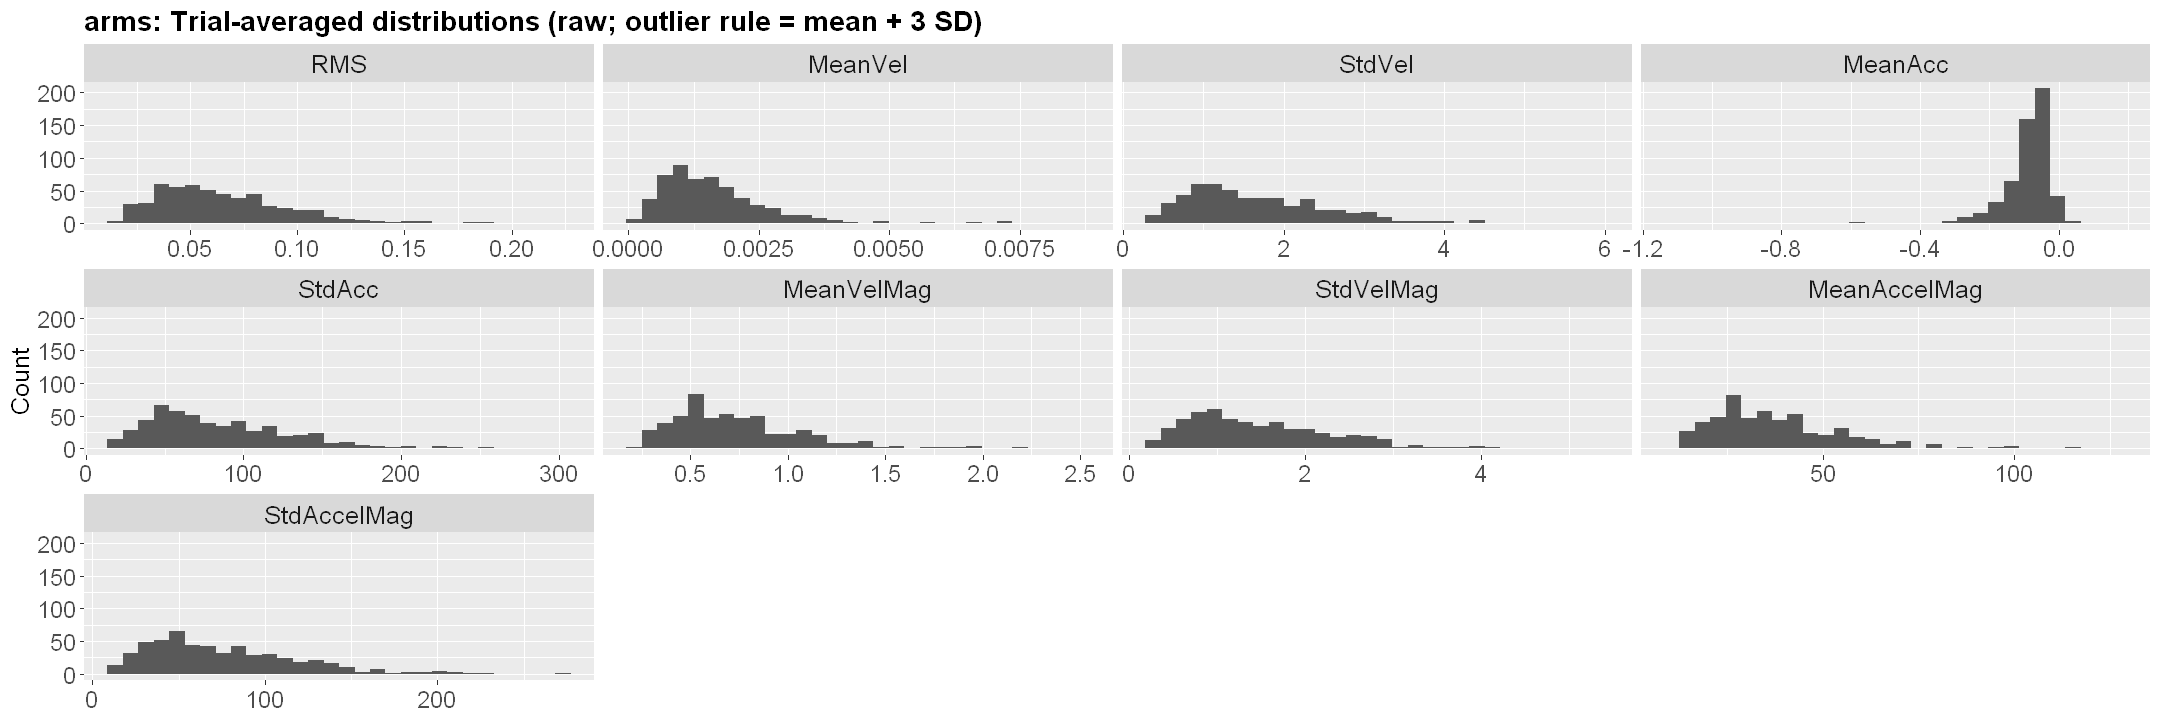

Warning message:
"Removed 36 rows containing non-finite outside the scale range (`stat_bin()`)."


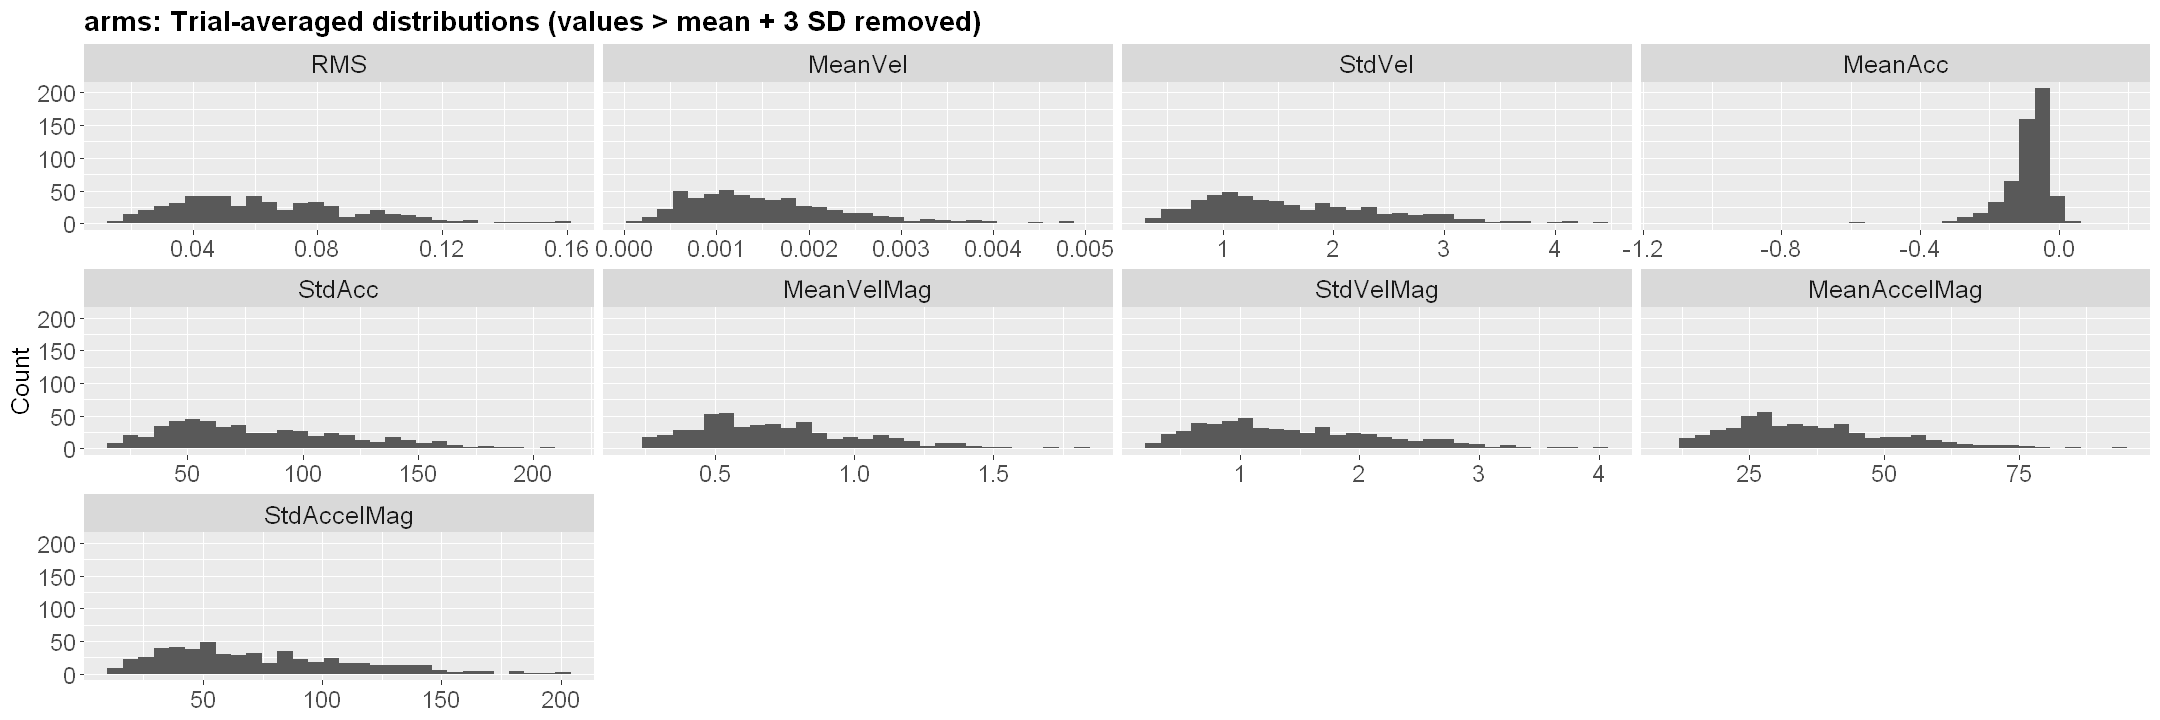


Outlier counts for ROI: body (rule = mean + 3 SD)
# A tibble: 9 × 4
  Metric       n_total n_removed prop_removed
  <chr>          <int>     <int>        <dbl>
1 RMS              546         8      0.01465
2 MeanVel          546         6      0.01099
3 StdVel           546         6      0.01099
4 MeanAcc          546         0      0      
5 StdAcc           546         7      0.01282
6 MeanVelMag       546         7      0.01282
7 StdVelMag        546         7      0.01282
8 MeanAccelMag     546         7      0.01282
9 StdAccelMag      546         7      0.01282


Warning message:
"Removed 36 rows containing non-finite outside the scale range (`stat_bin()`)."


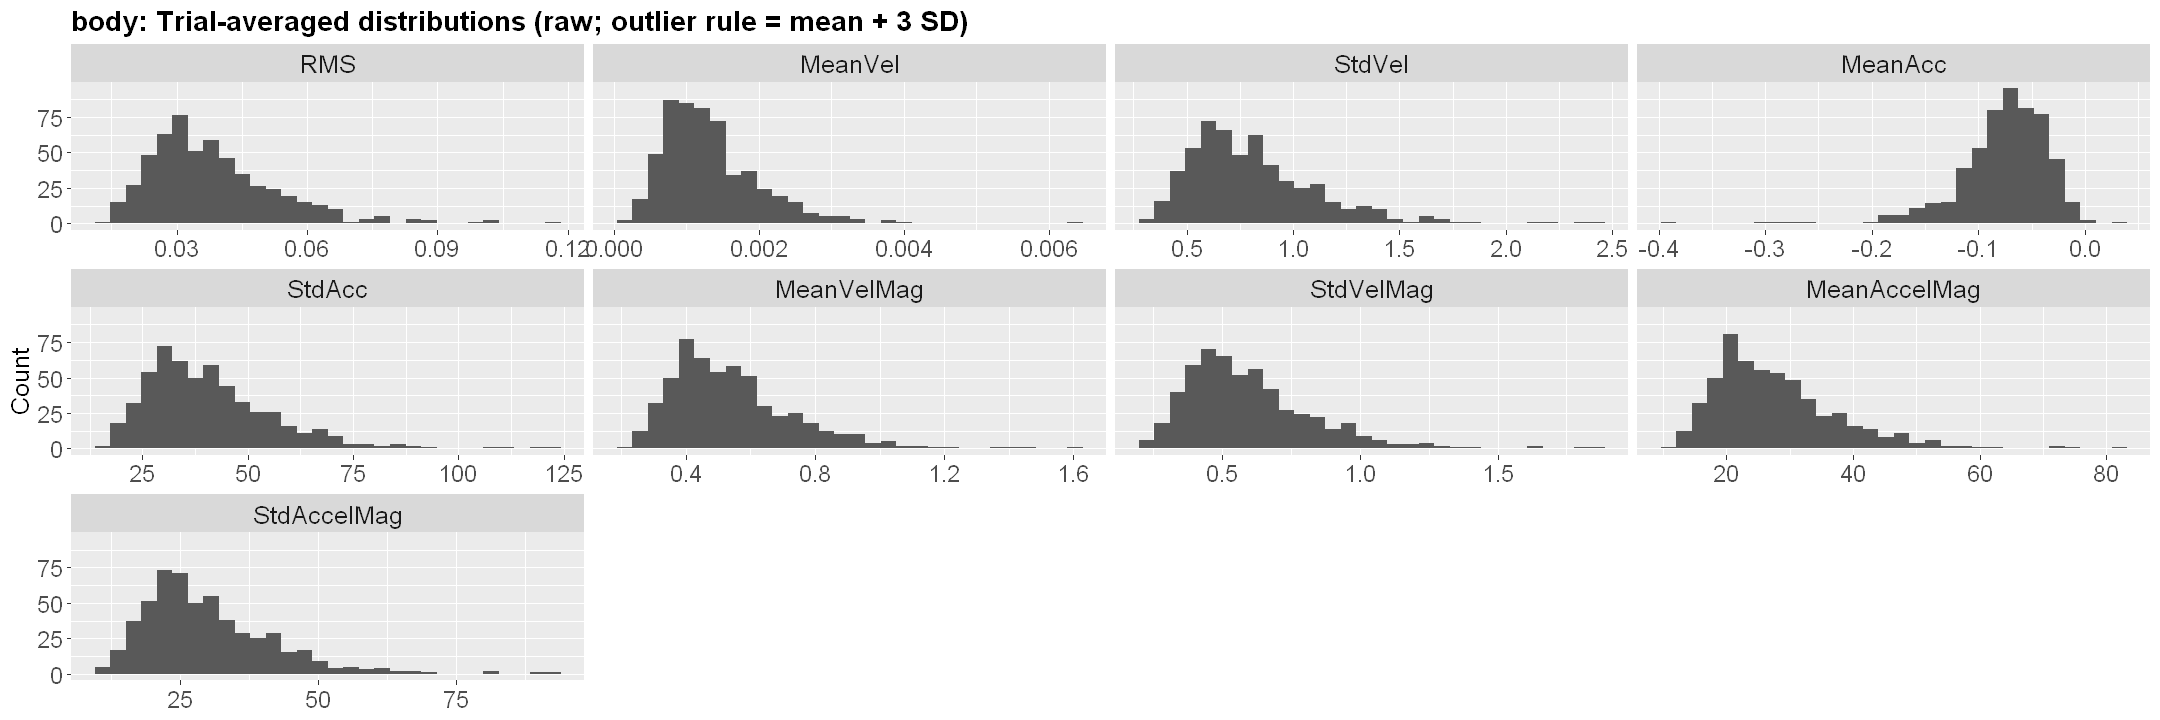

Warning message:
"Removed 36 rows containing non-finite outside the scale range (`stat_bin()`)."


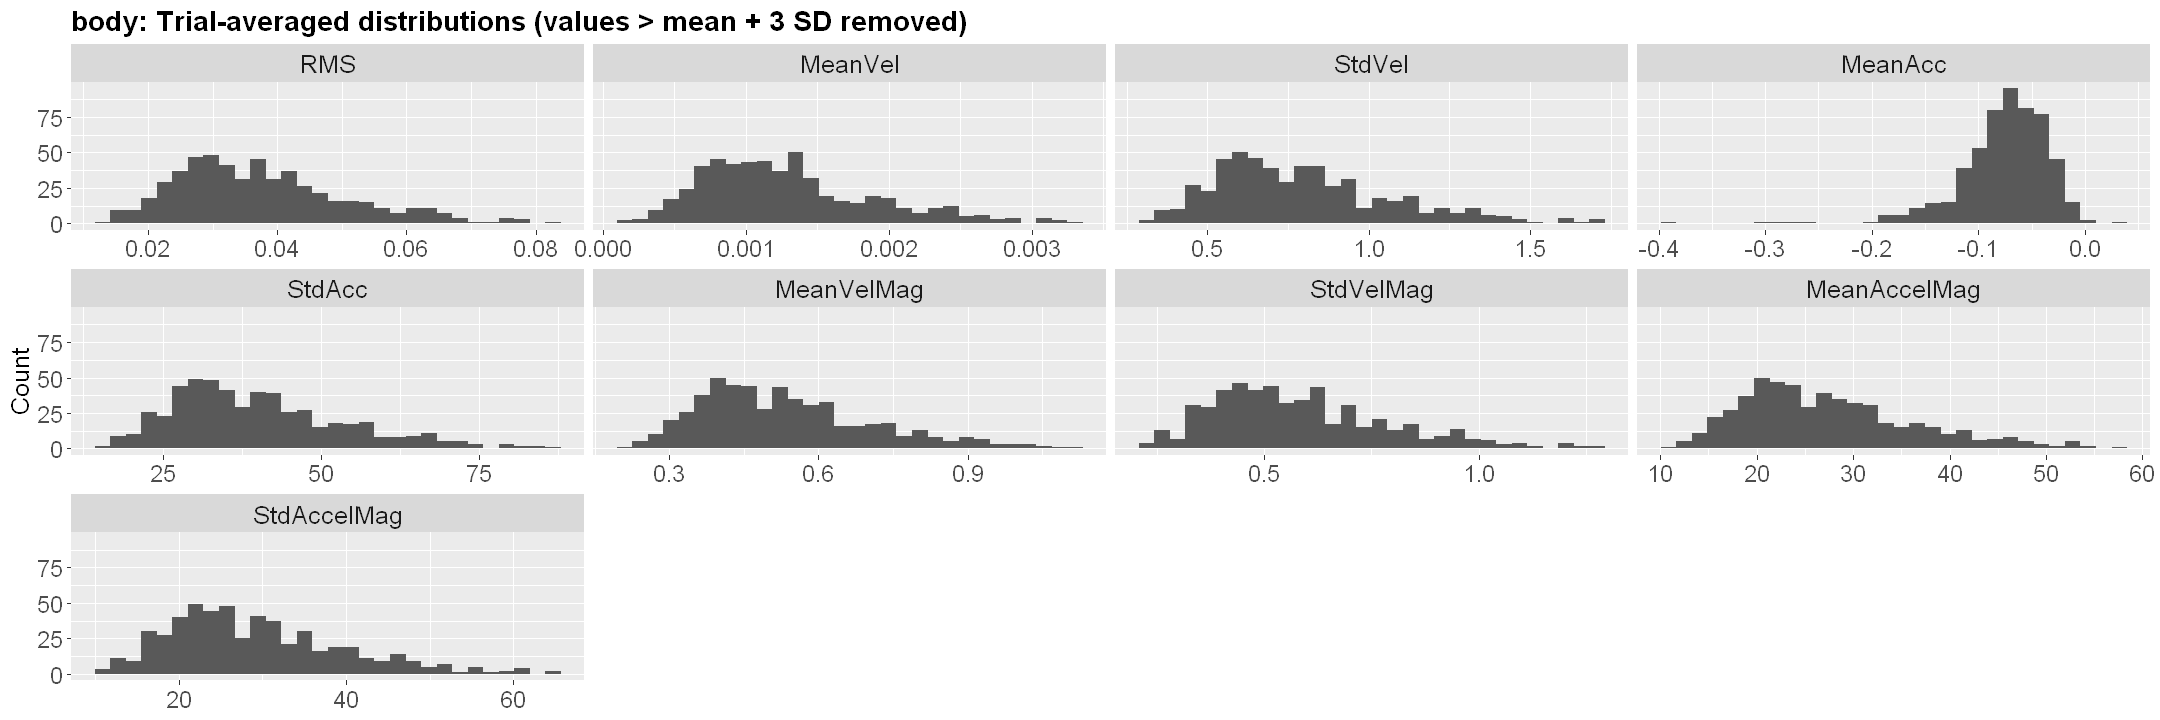


Outlier counts for ROI: center_face (rule = mean + 3 SD)
# A tibble: 9 × 4
  Metric       n_total n_removed prop_removed
  <chr>          <int>     <int>        <dbl>
1 RMS              546         7      0.01282
2 MeanVel          546         9      0.01648
3 StdVel           546         7      0.01282
4 MeanAcc          546         0      0      
5 StdAcc           546         6      0.01099
6 MeanVelMag       546         7      0.01282
7 StdVelMag        546         7      0.01282
8 MeanAccelMag     546         6      0.01099
9 StdAccelMag      546         6      0.01099


Warning message:
"Removed 36 rows containing non-finite outside the scale range (`stat_bin()`)."


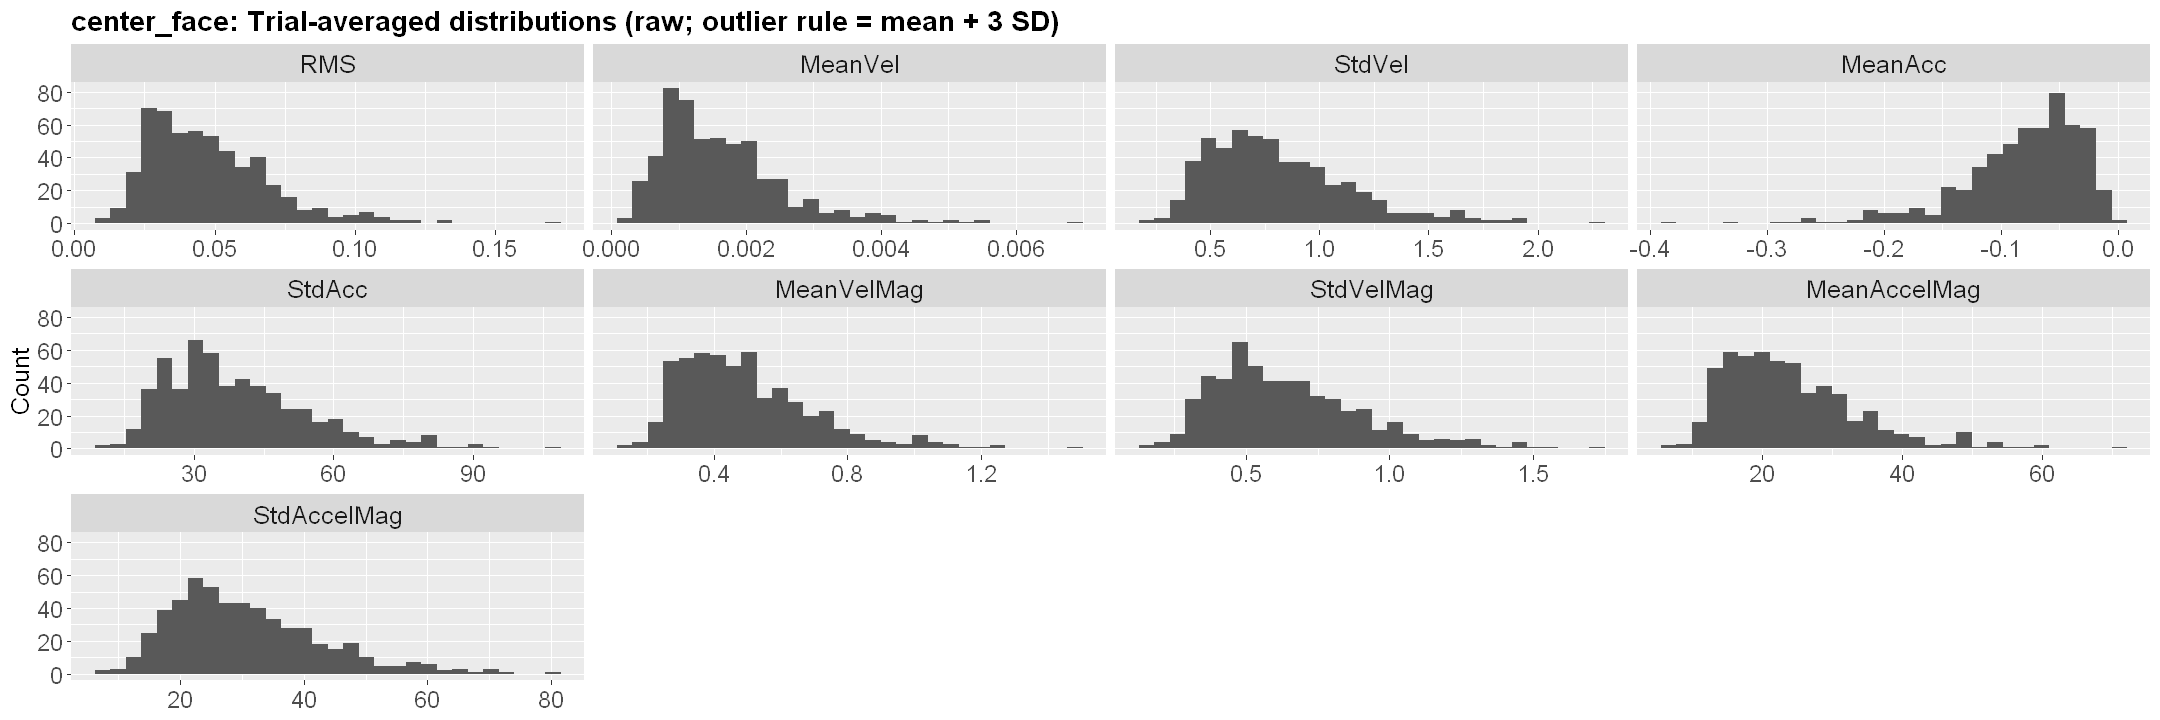

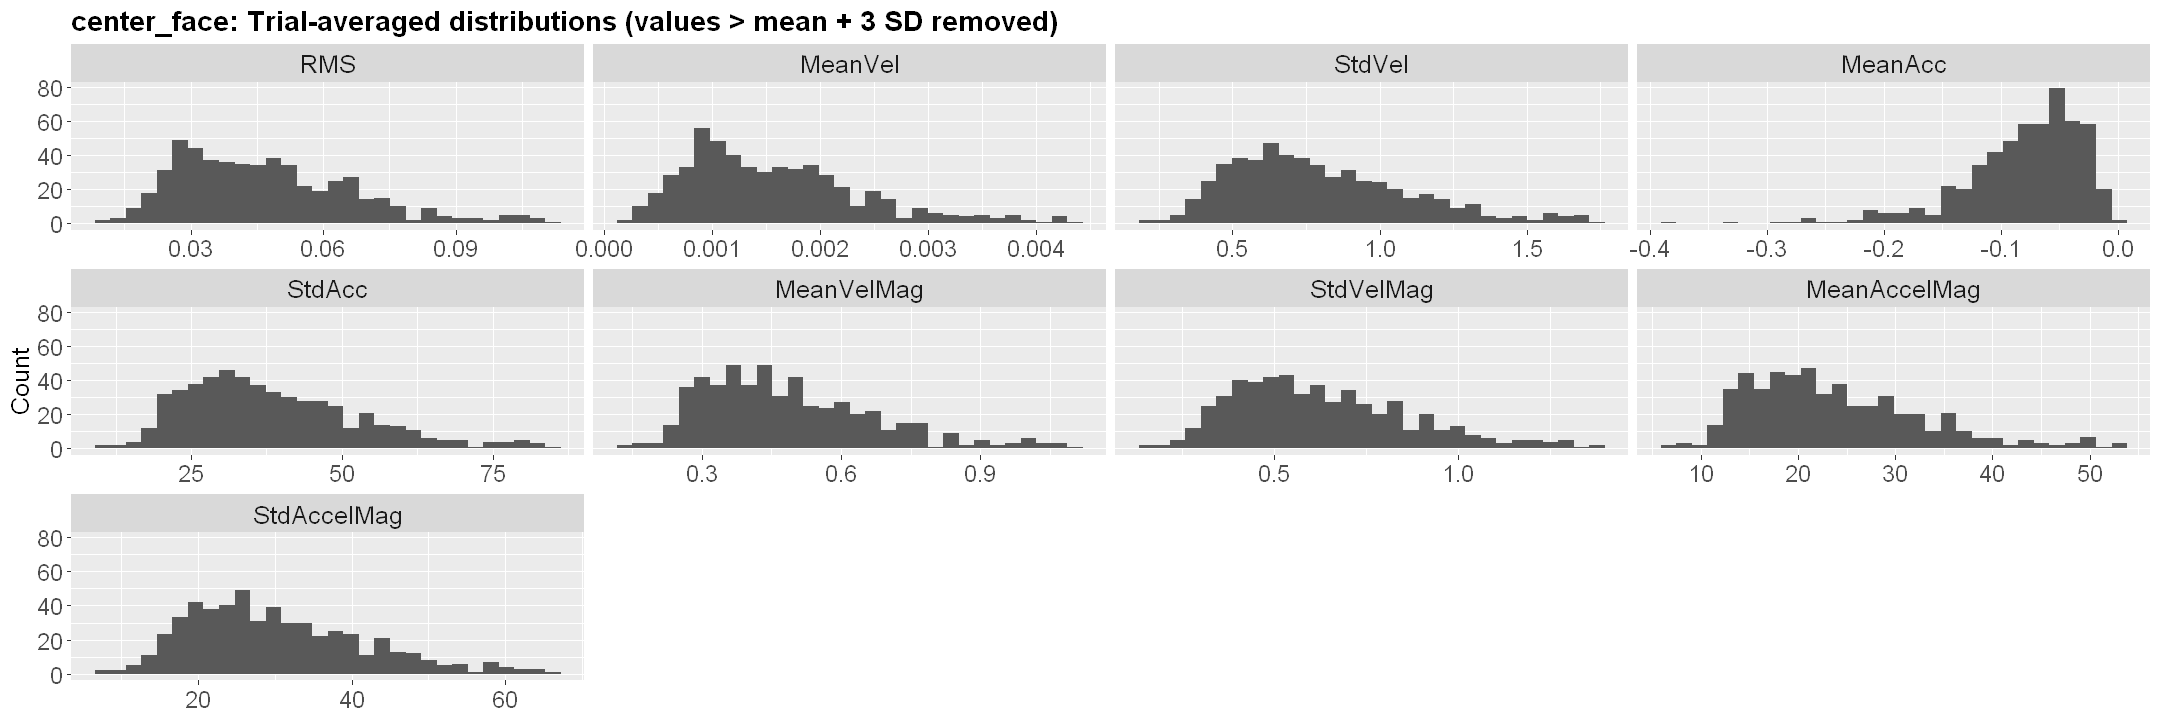

In [ ]:
# Settings
SD_CUTOFF <- 3
N_COLS    <- 4
N_BINS    <- 30

# Order of metrics for plotting
metric_order <- c(
  "RMS","MeanVel","StdVel","MeanAcc","StdAcc","MeanVelMag","StdVelMag","MeanAccelMag","StdAccelMag"
)

# Convert data to long format for plotting
linear_long <- linear_av %>%
  pivot_longer(all_of(metric_order), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric   = as.character(Metric),
    Metric_f = factor(Metric, levels = metric_order)
  )

# Set plot size
options(repr.plot.width = 18, repr.plot.height = 6)

# Run all ROIs
for (roi in sort(unique(linear_long$ROI))) {
  plot_roi_hists(roi, linear_long, sd_cutoff = SD_CUTOFF, ncol = N_COLS)
}

#### Cross-correlation features

Warning message:
"Removed 40 rows containing non-finite outside the scale range (`stat_bin()`)."



Outlier counts for ROI: arms (rule = mean + 3 SD)
# A tibble: 4 × 4
  Metric                n_total n_removed prop_removed
  <chr>                   <int>     <int>        <dbl>
1 XCorr_VelMag_rmax         268         2     0.007463
2 XCorr_VelMag_rmax_abs     268         2     0.007463
3 XCorr_VelMag_r0           268         3     0.01119 
4 XCorr_VelMag_r0_abs       268         5     0.01866 


Warning message:
"Removed 40 rows containing non-finite outside the scale range (`stat_bin()`)."


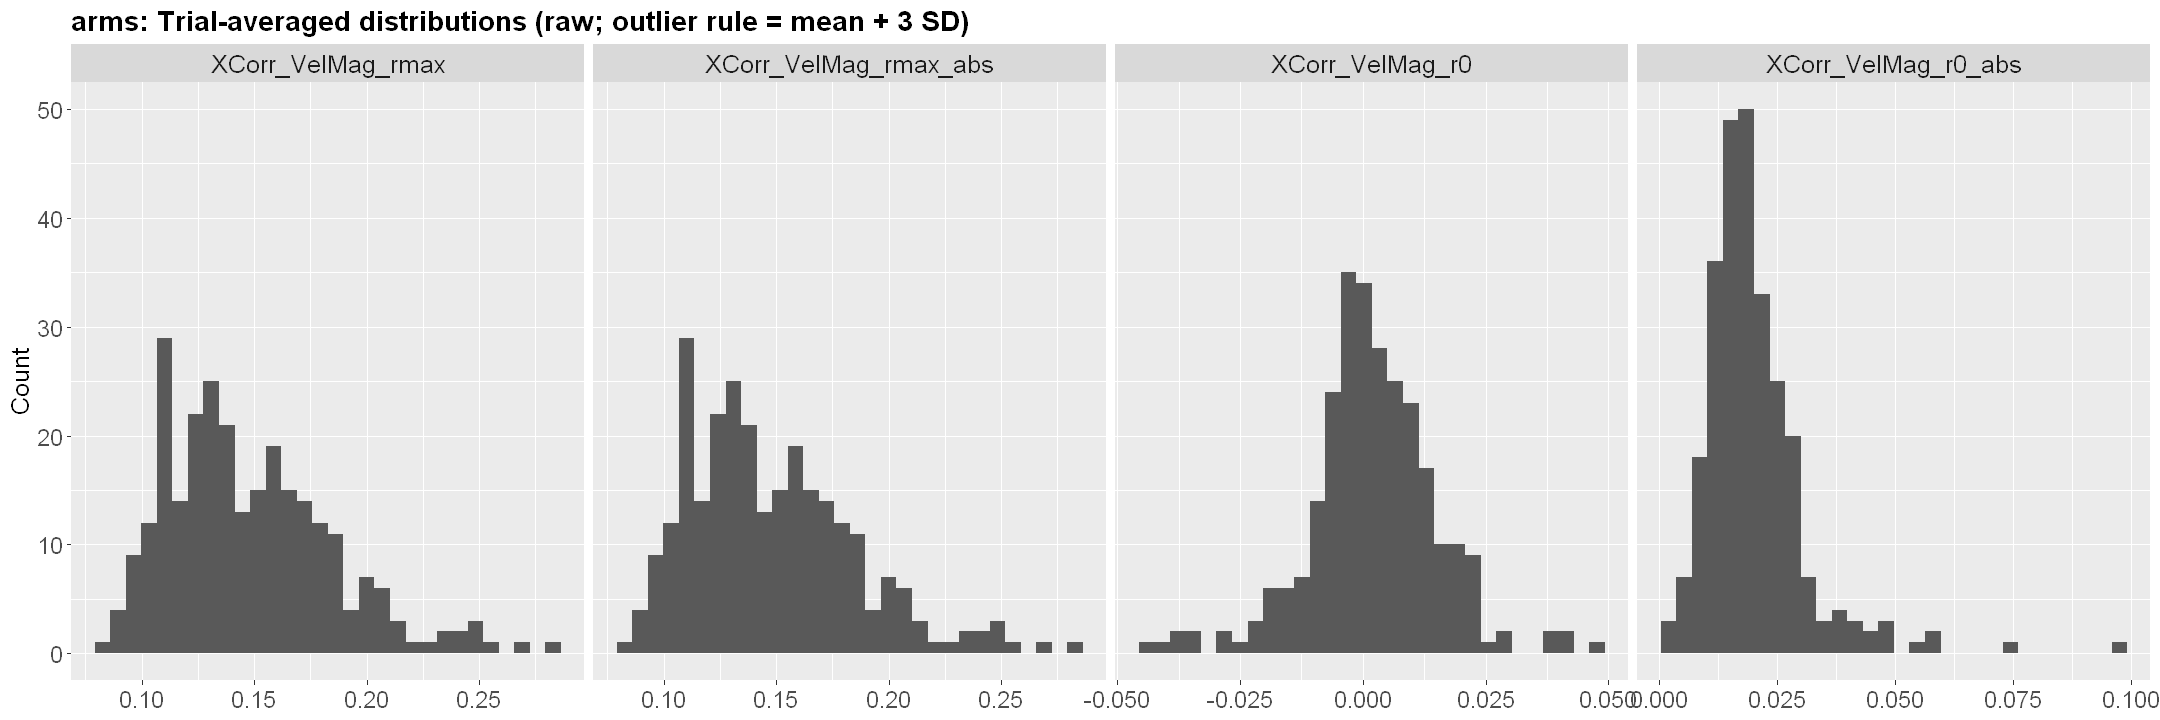

Warning message:
"Removed 40 rows containing non-finite outside the scale range (`stat_bin()`)."


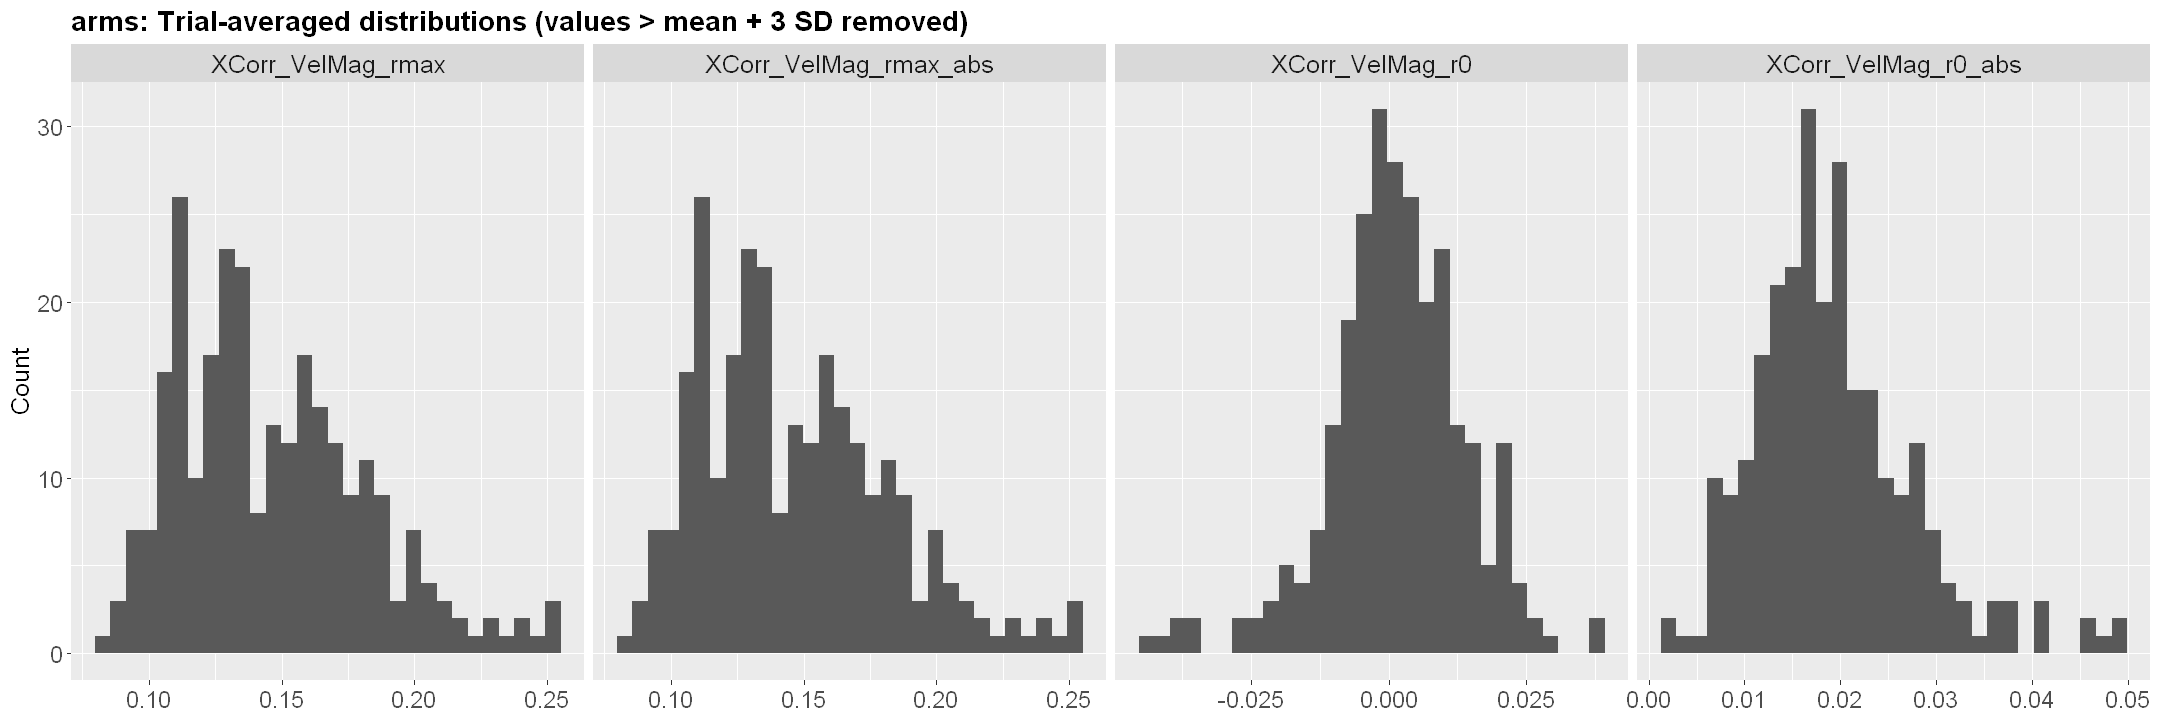


Outlier counts for ROI: body (rule = mean + 3 SD)
# A tibble: 4 × 4
  Metric                n_total n_removed prop_removed
  <chr>                   <int>     <int>        <dbl>
1 XCorr_VelMag_rmax         268         4     0.01493 
2 XCorr_VelMag_rmax_abs     268         4     0.01493 
3 XCorr_VelMag_r0           268         2     0.007463
4 XCorr_VelMag_r0_abs       268         4     0.01493 


Warning message:
"Removed 40 rows containing non-finite outside the scale range (`stat_bin()`)."


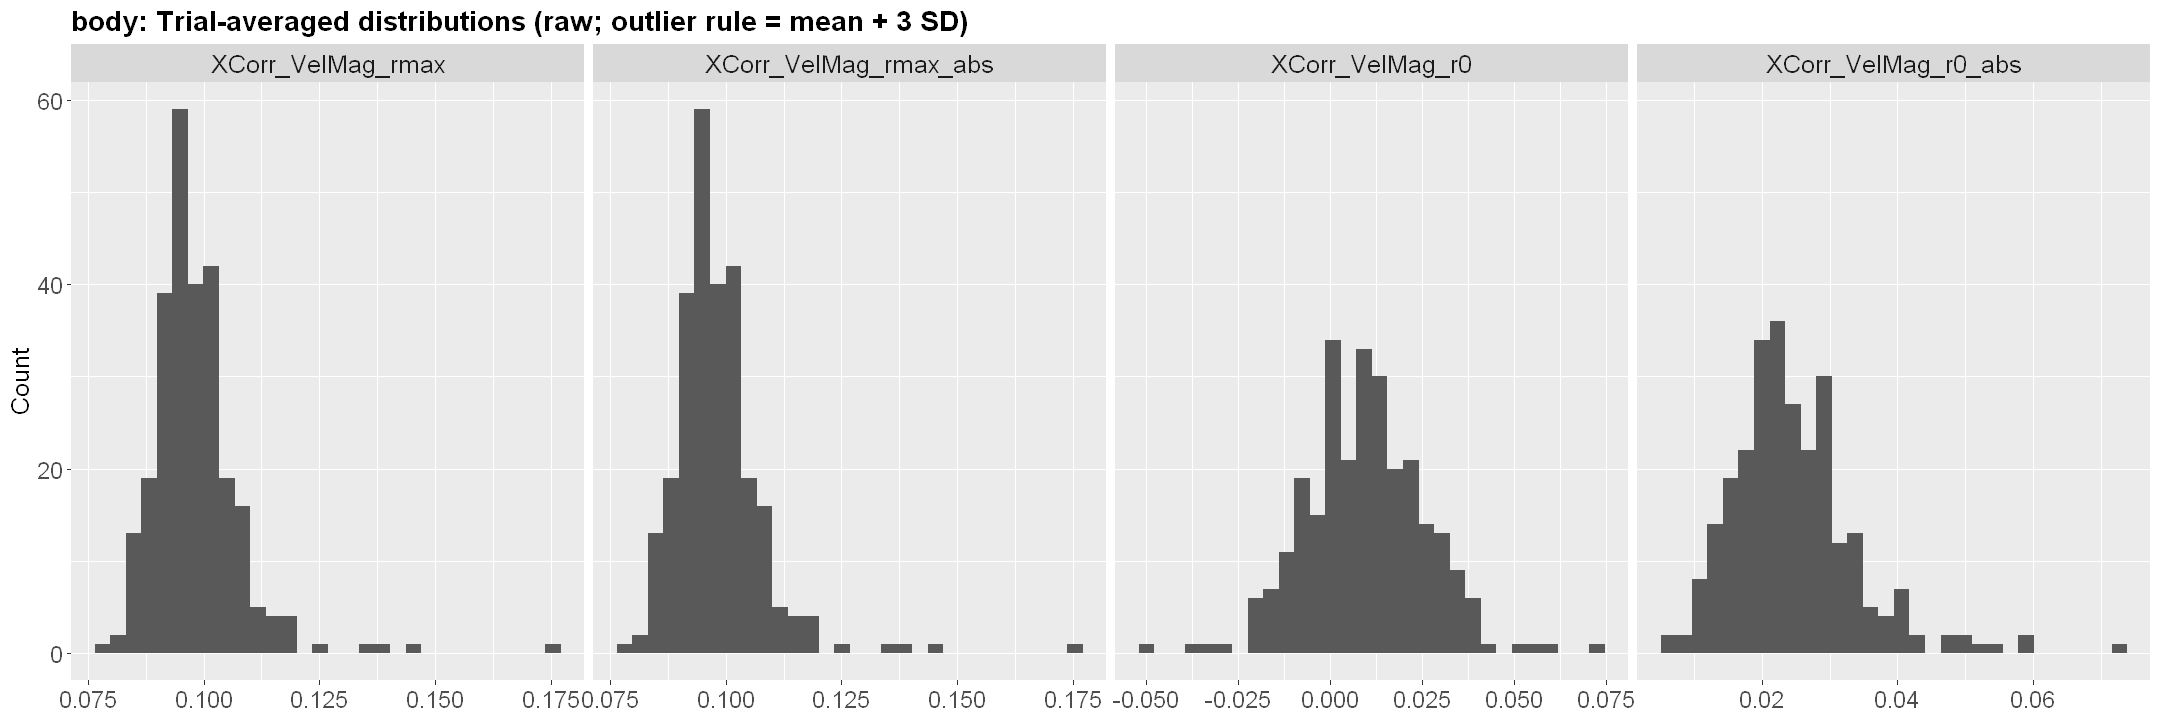

Warning message:
"Removed 40 rows containing non-finite outside the scale range (`stat_bin()`)."


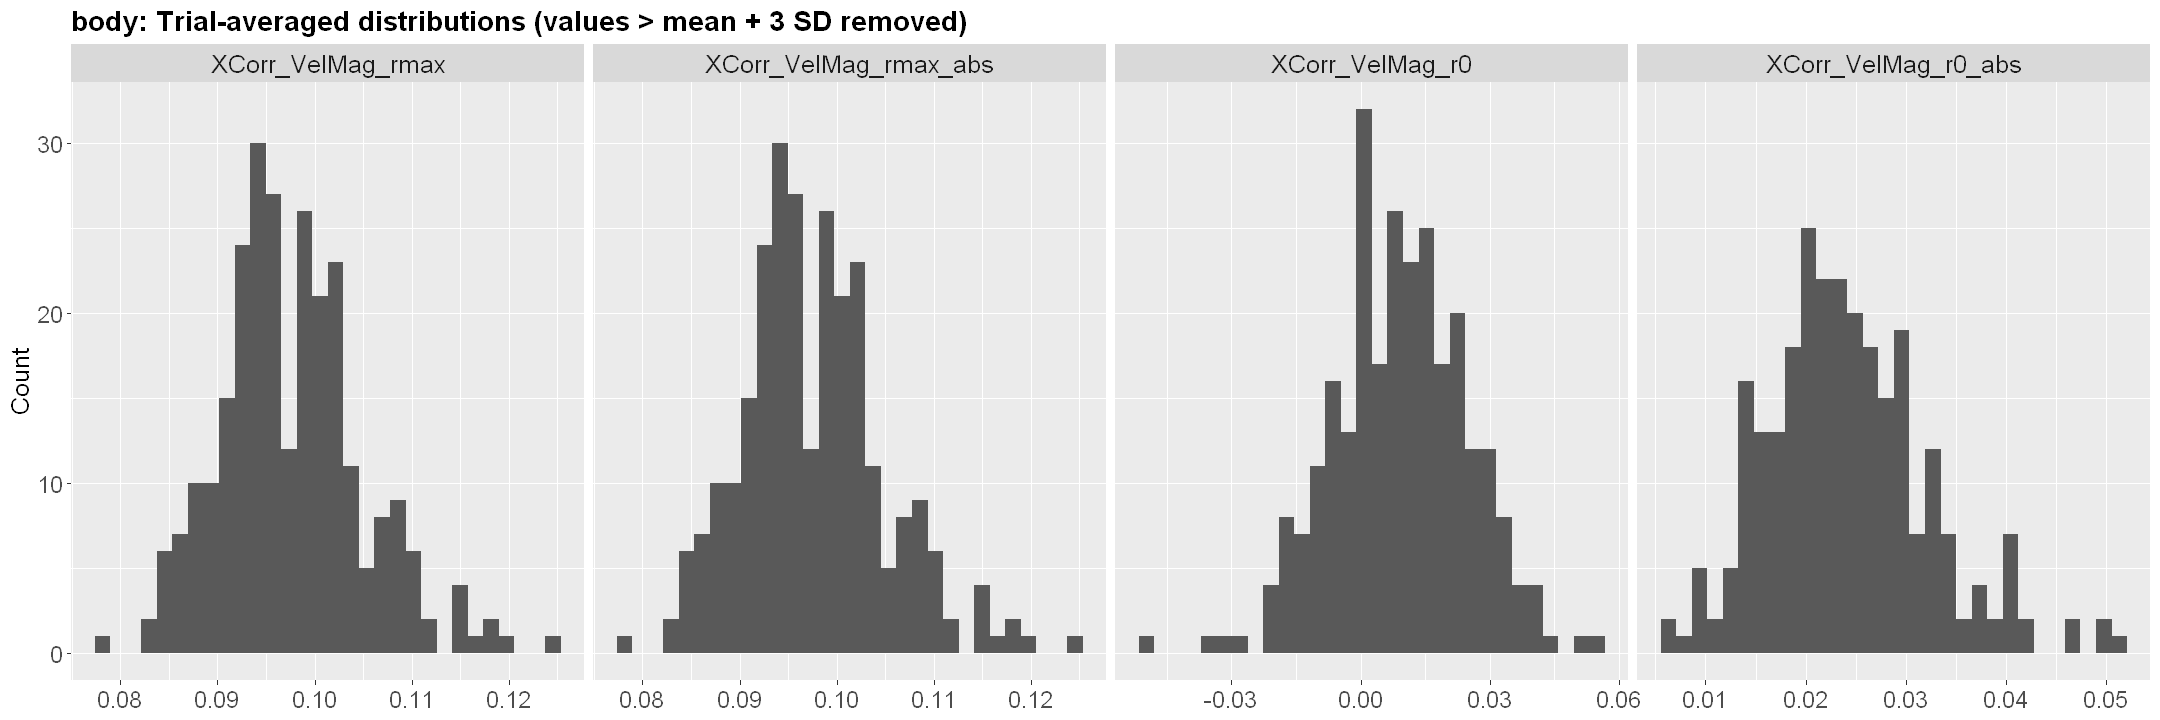


Outlier counts for ROI: center_face (rule = mean + 3 SD)
# A tibble: 4 × 4
  Metric                n_total n_removed prop_removed
  <chr>                   <int>     <int>        <dbl>
1 XCorr_VelMag_rmax         268         2     0.007463
2 XCorr_VelMag_rmax_abs     268         2     0.007463
3 XCorr_VelMag_r0           268         3     0.01119 
4 XCorr_VelMag_r0_abs       268         5     0.01866 


Warning message:
"Removed 40 rows containing non-finite outside the scale range (`stat_bin()`)."


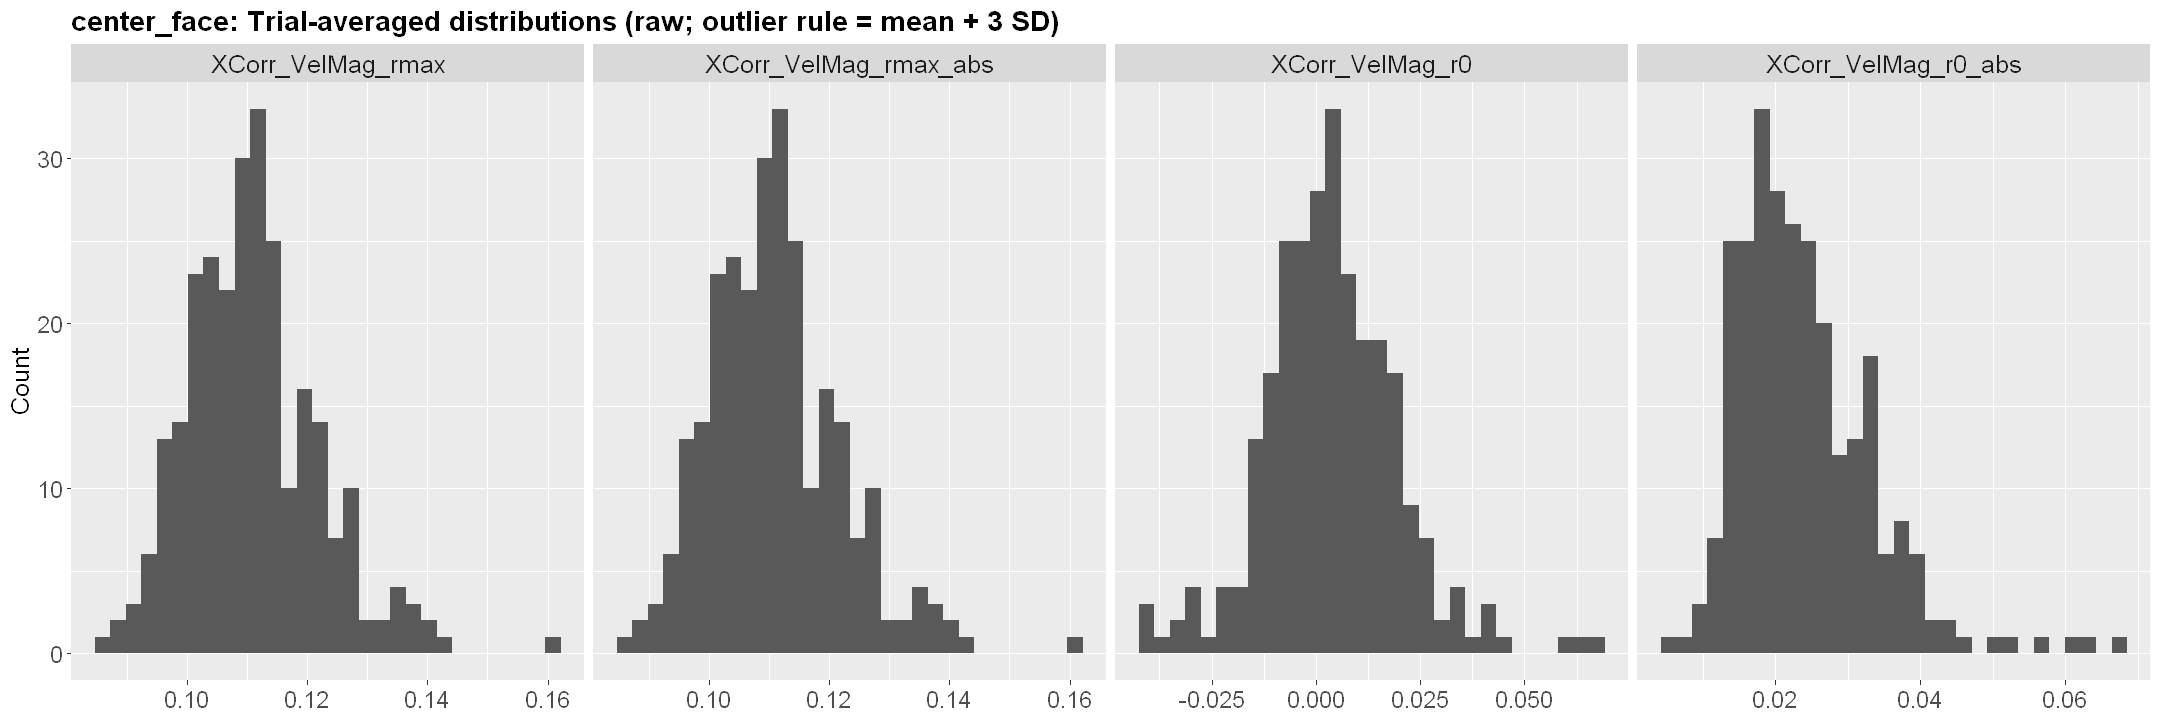

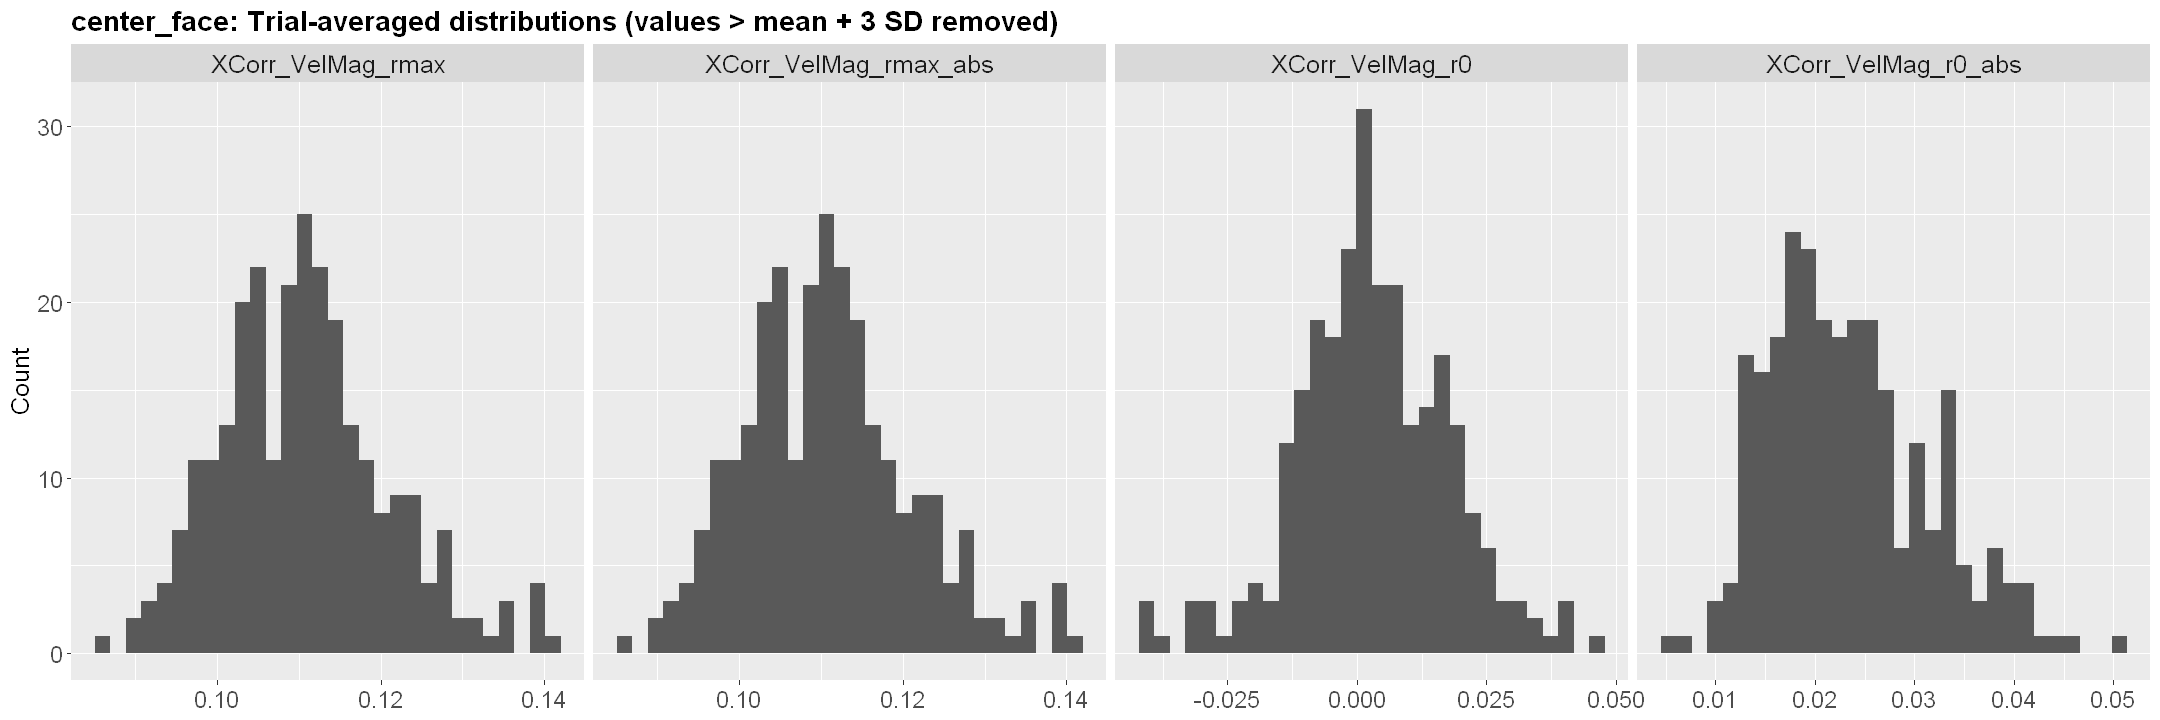

In [ ]:
# Settings
SD_CUTOFF <- 3
N_COLS    <- 4
N_BINS    <- 30

# Order of metrics for plotting
metric_order <- c(
  "XCorr_VelMag_rmax", "XCorr_VelMag_rmax_abs", "XCorr_VelMag_r0", "XCorr_VelMag_r0_abs" 
)

# Convert data to long format for plotting
xcorr_long <- xcorr_av %>%
  pivot_longer(all_of(metric_order), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric   = as.character(Metric),
    Metric_f = factor(Metric, levels = metric_order)
  )

# Set plot size
options(repr.plot.width = 18, repr.plot.height = 6)

# Run all ROIs
for (roi in sort(unique(xcorr_long$ROI))) {
  plot_roi_hists(roi, xcorr_long, sd_cutoff = SD_CUTOFF, ncol = N_COLS)
}

#### Cross recurrence features


Outlier counts for ROI: arms (rule = mean + 3 SD)
# A tibble: 7 × 4
  Metric     n_total n_removed prop_removed
  <chr>        <int>     <int>        <dbl>
1 CRQA_REC       268         4     0.01493 
2 CRQA_DET       268         1     0.003731
3 CRQA_Lmean     268         4     0.01493 
4 CRQA_Lmax      268         4     0.01493 
5 CRQA_ENT       268         1     0.003731
6 CRQA_LAM       268         0     0       
7 CRQA_TT        268         3     0.01119 


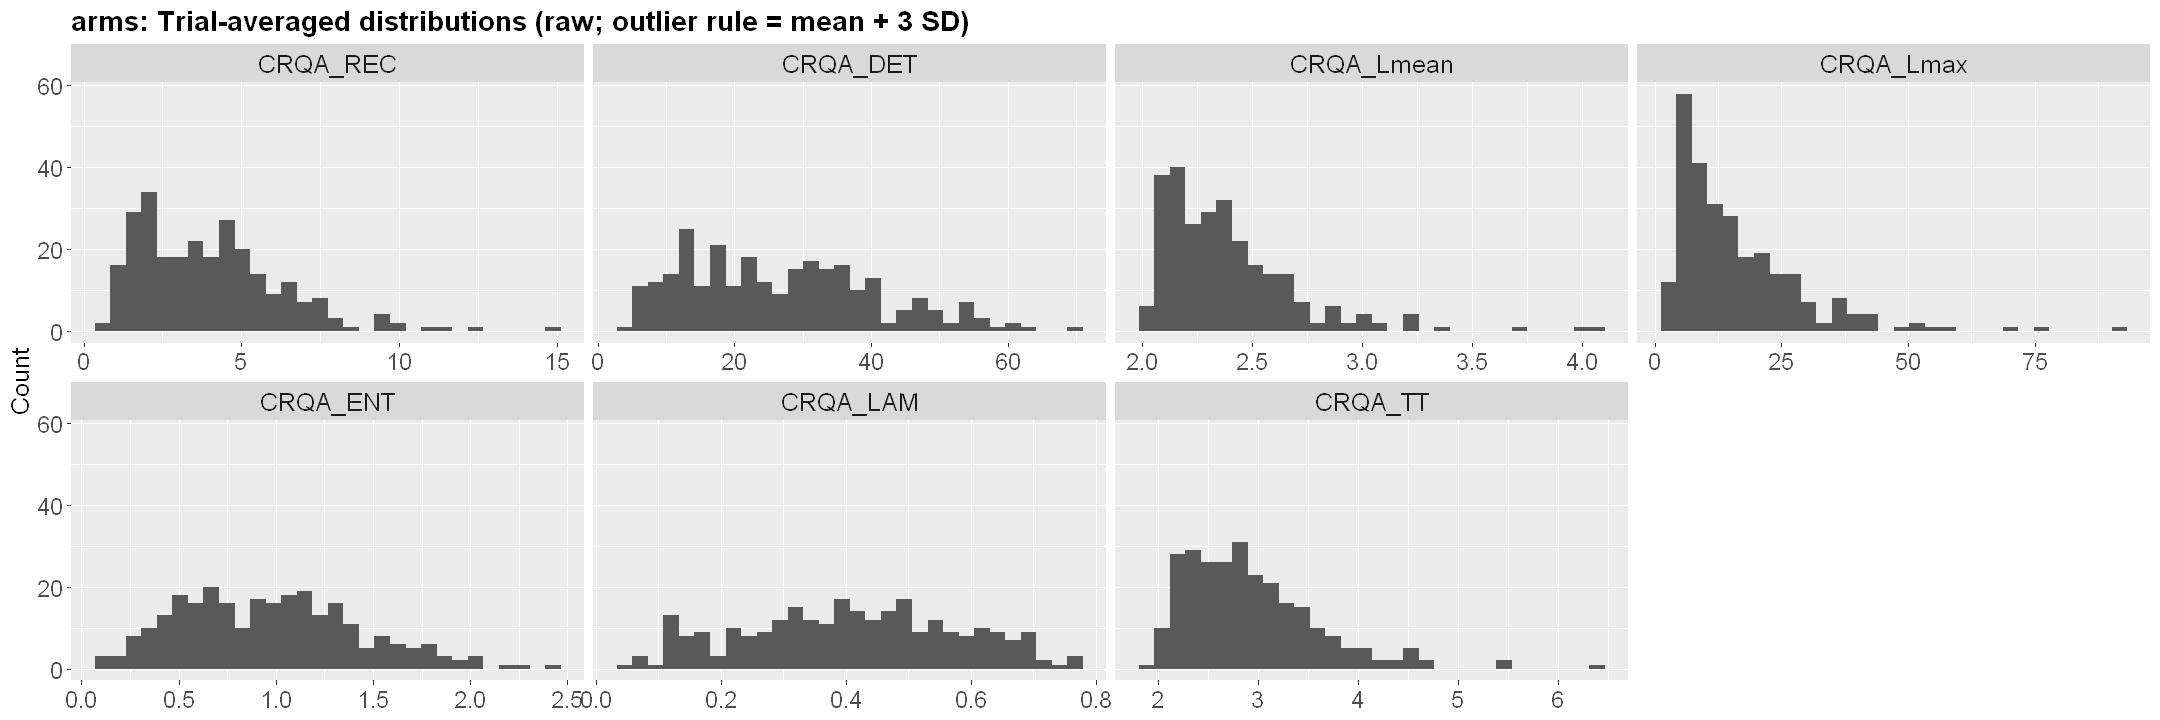

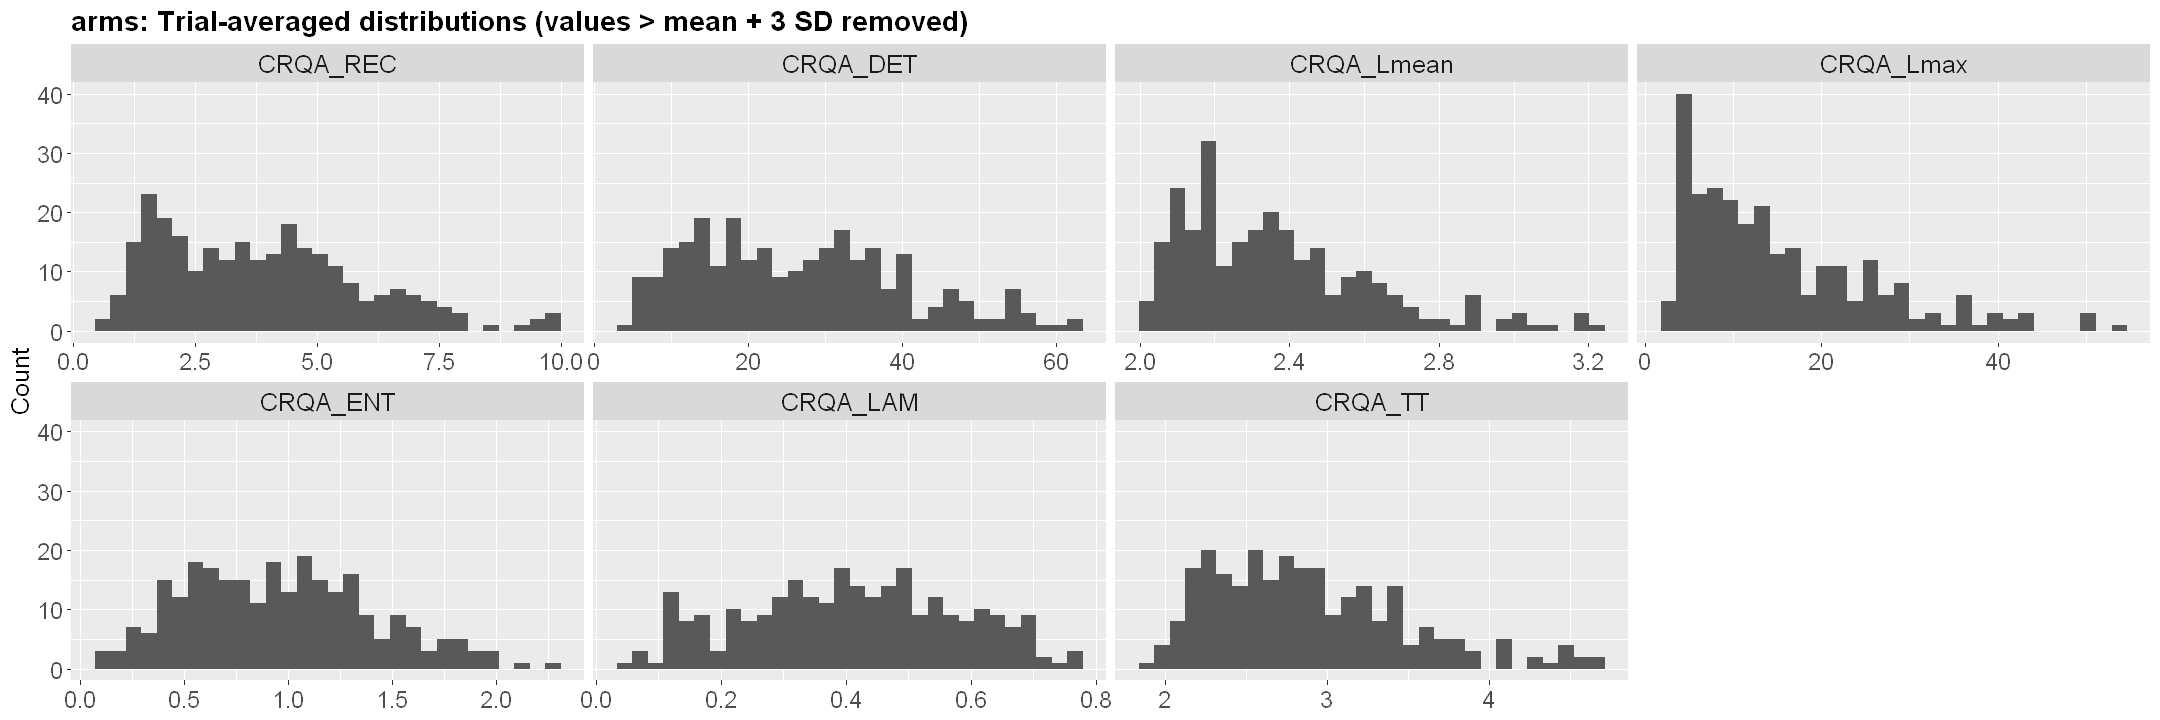


Outlier counts for ROI: body (rule = mean + 3 SD)
# A tibble: 7 × 4
  Metric     n_total n_removed prop_removed
  <chr>        <int>     <int>        <dbl>
1 CRQA_REC       268         5      0.01866
2 CRQA_DET       268         5      0.01866
3 CRQA_Lmean     268         4      0.01493
4 CRQA_Lmax      268         5      0.01866
5 CRQA_ENT       268         4      0.01493
6 CRQA_LAM       268         3      0.01119
7 CRQA_TT        268         5      0.01866


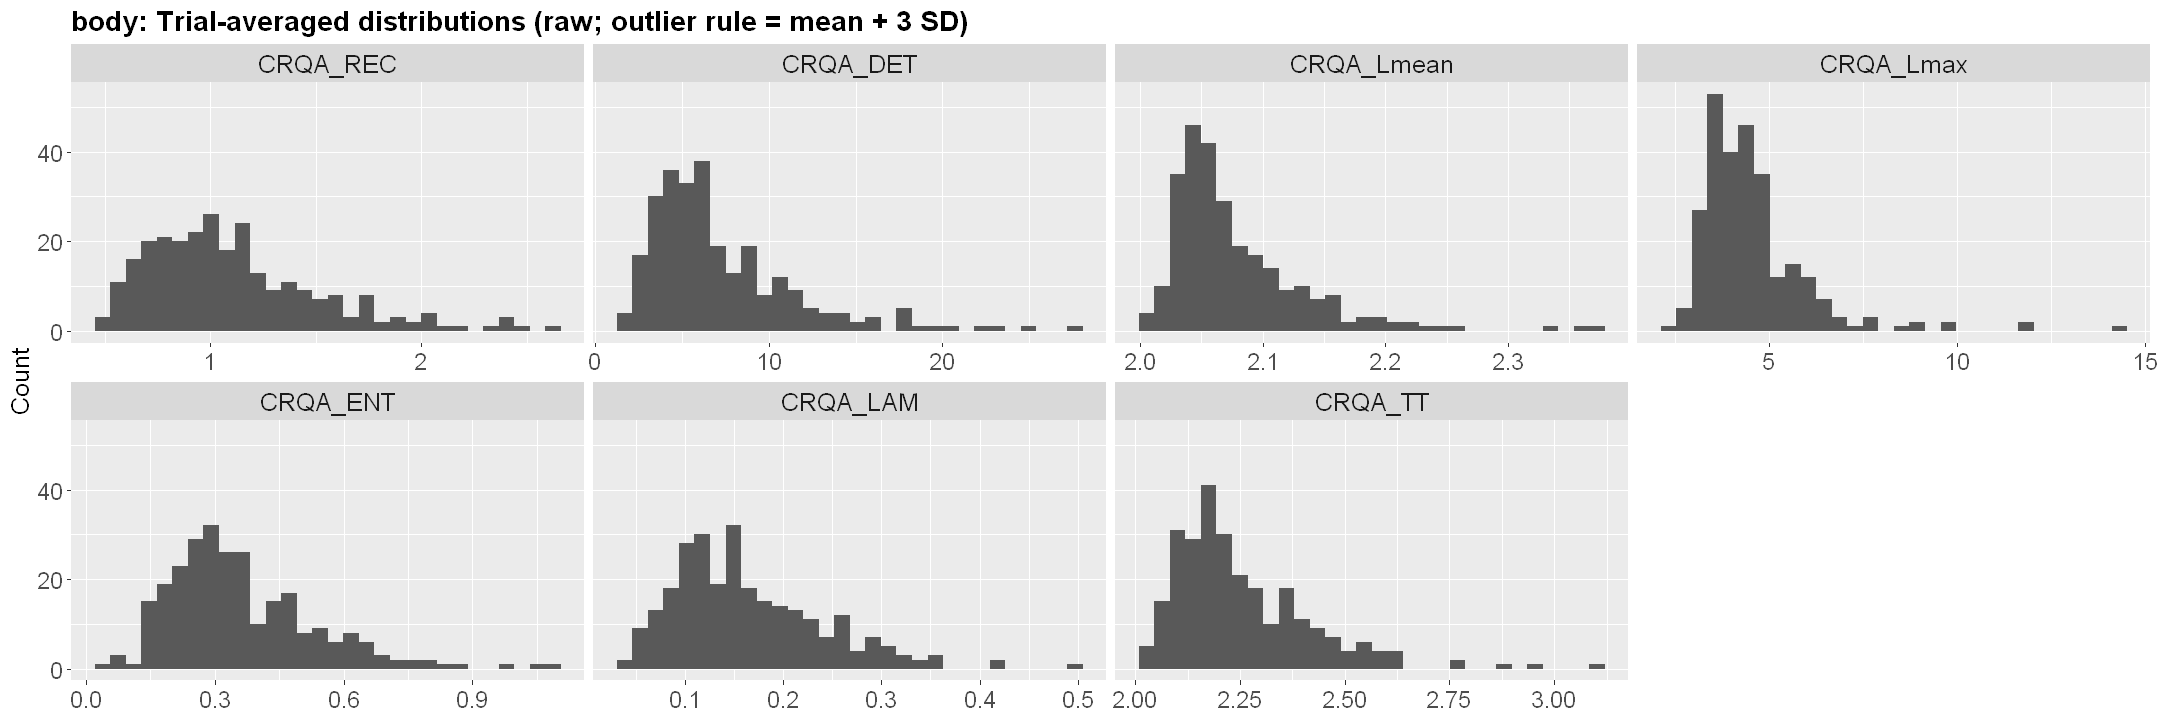

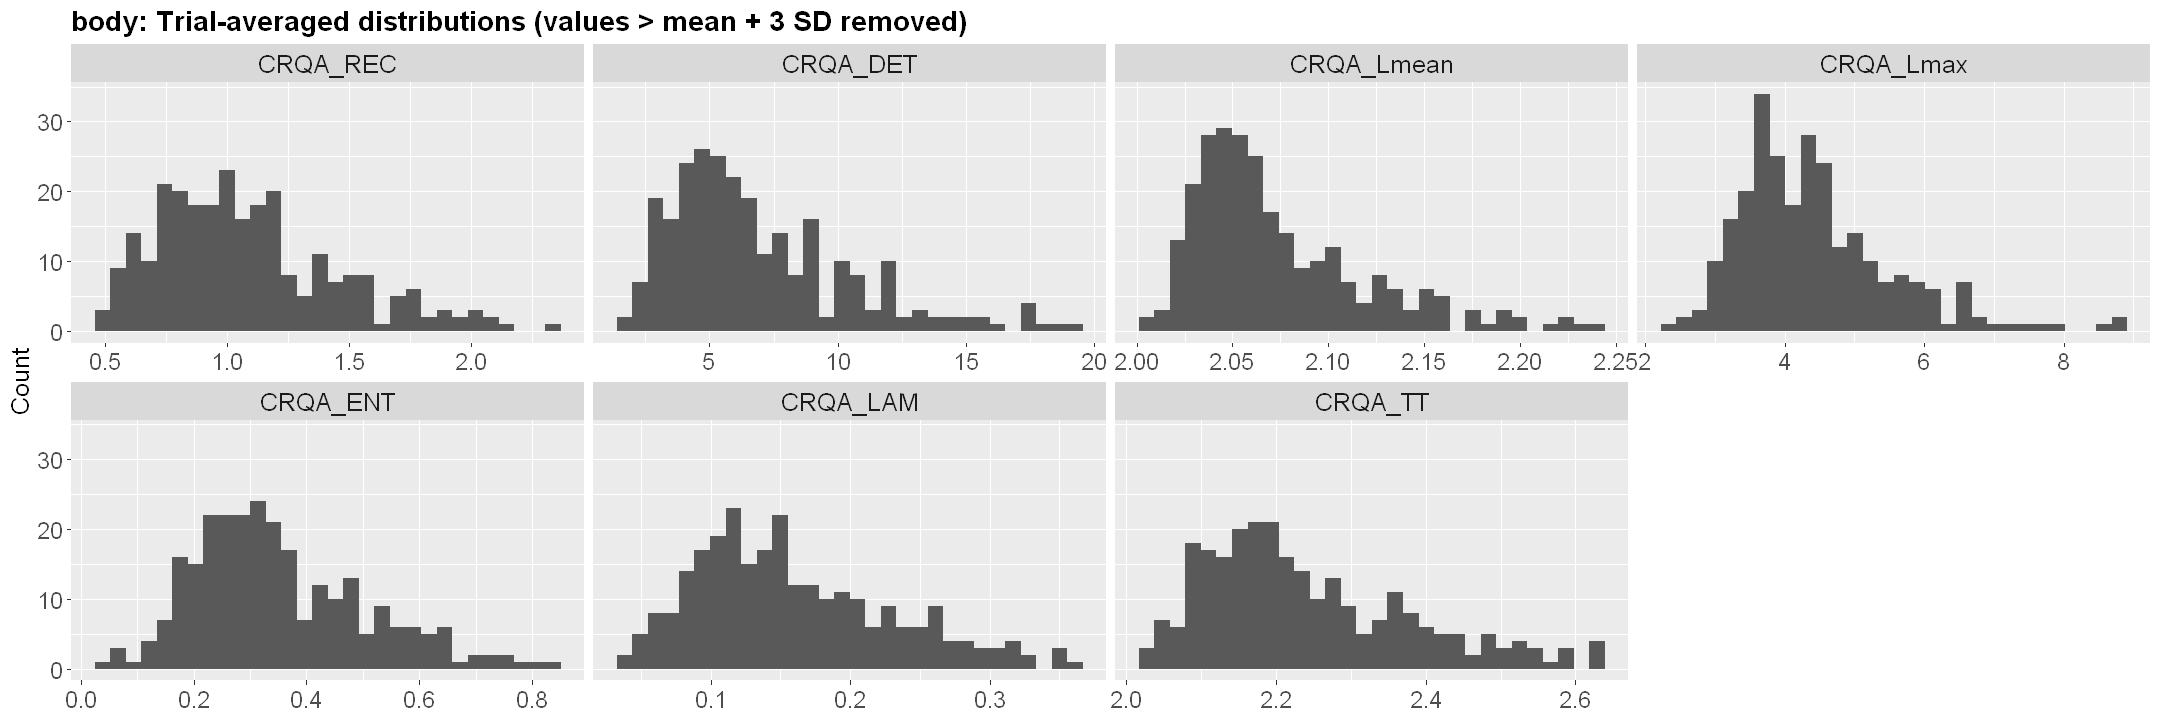


Outlier counts for ROI: center_face (rule = mean + 3 SD)
# A tibble: 7 × 4
  Metric     n_total n_removed prop_removed
  <chr>        <int>     <int>        <dbl>
1 CRQA_REC       268         6      0.02239
2 CRQA_DET       268         0      0      
3 CRQA_Lmean     268         5      0.01866
4 CRQA_Lmax      268         3      0.01119
5 CRQA_ENT       268         0      0      
6 CRQA_LAM       268         0      0      
7 CRQA_TT        268         6      0.02239


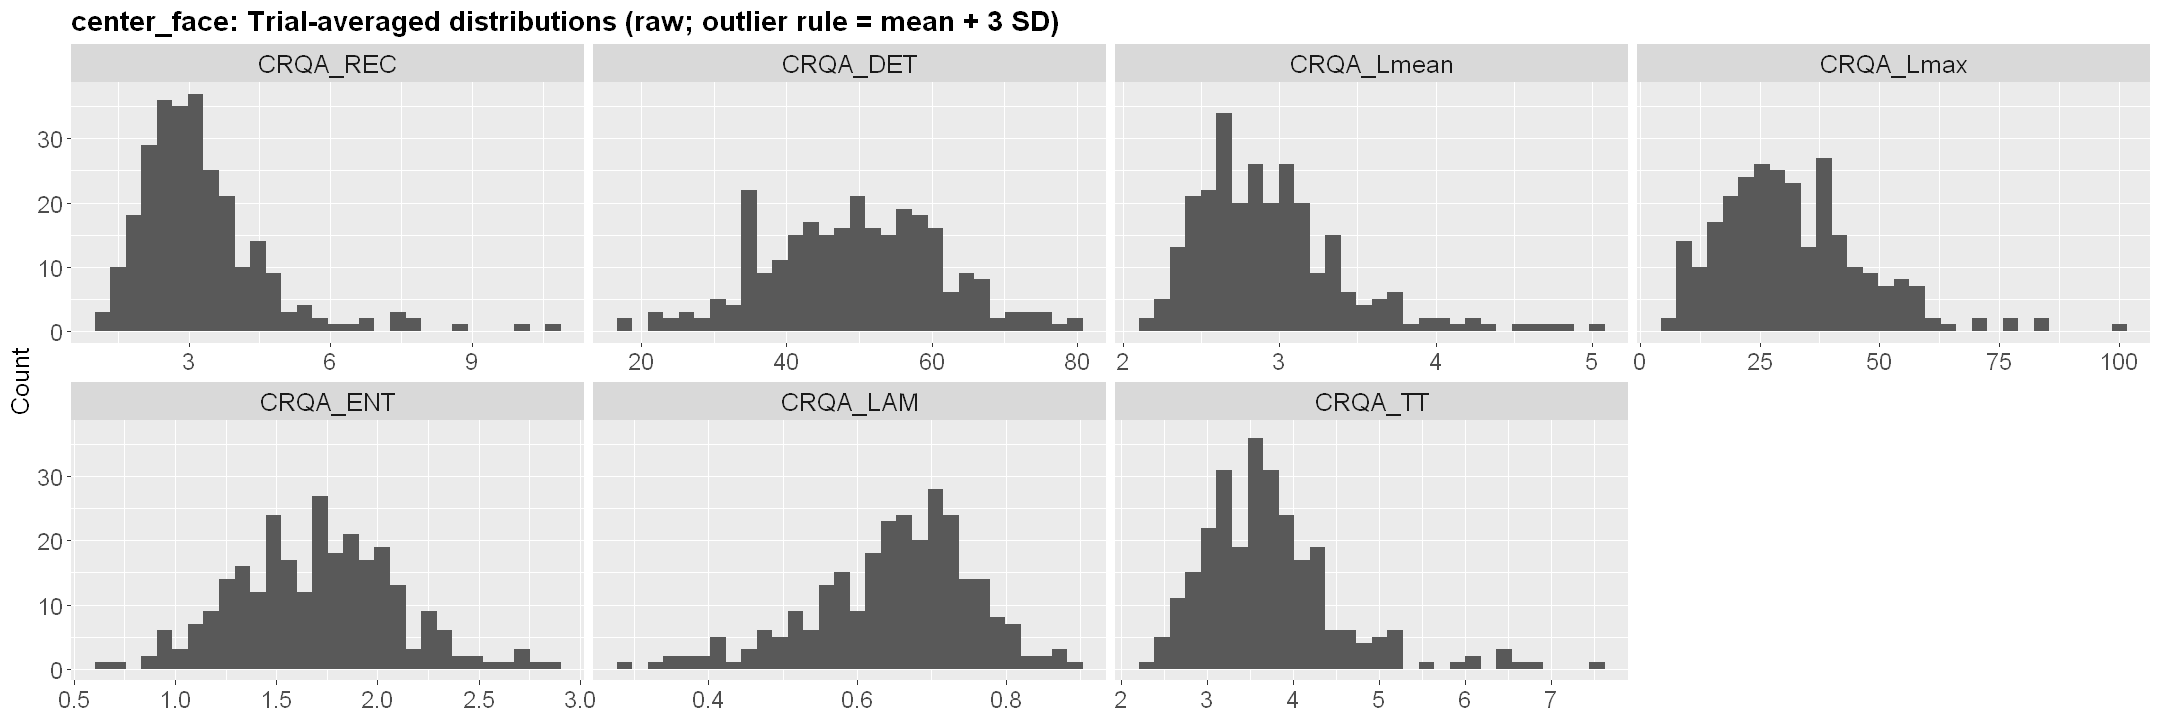

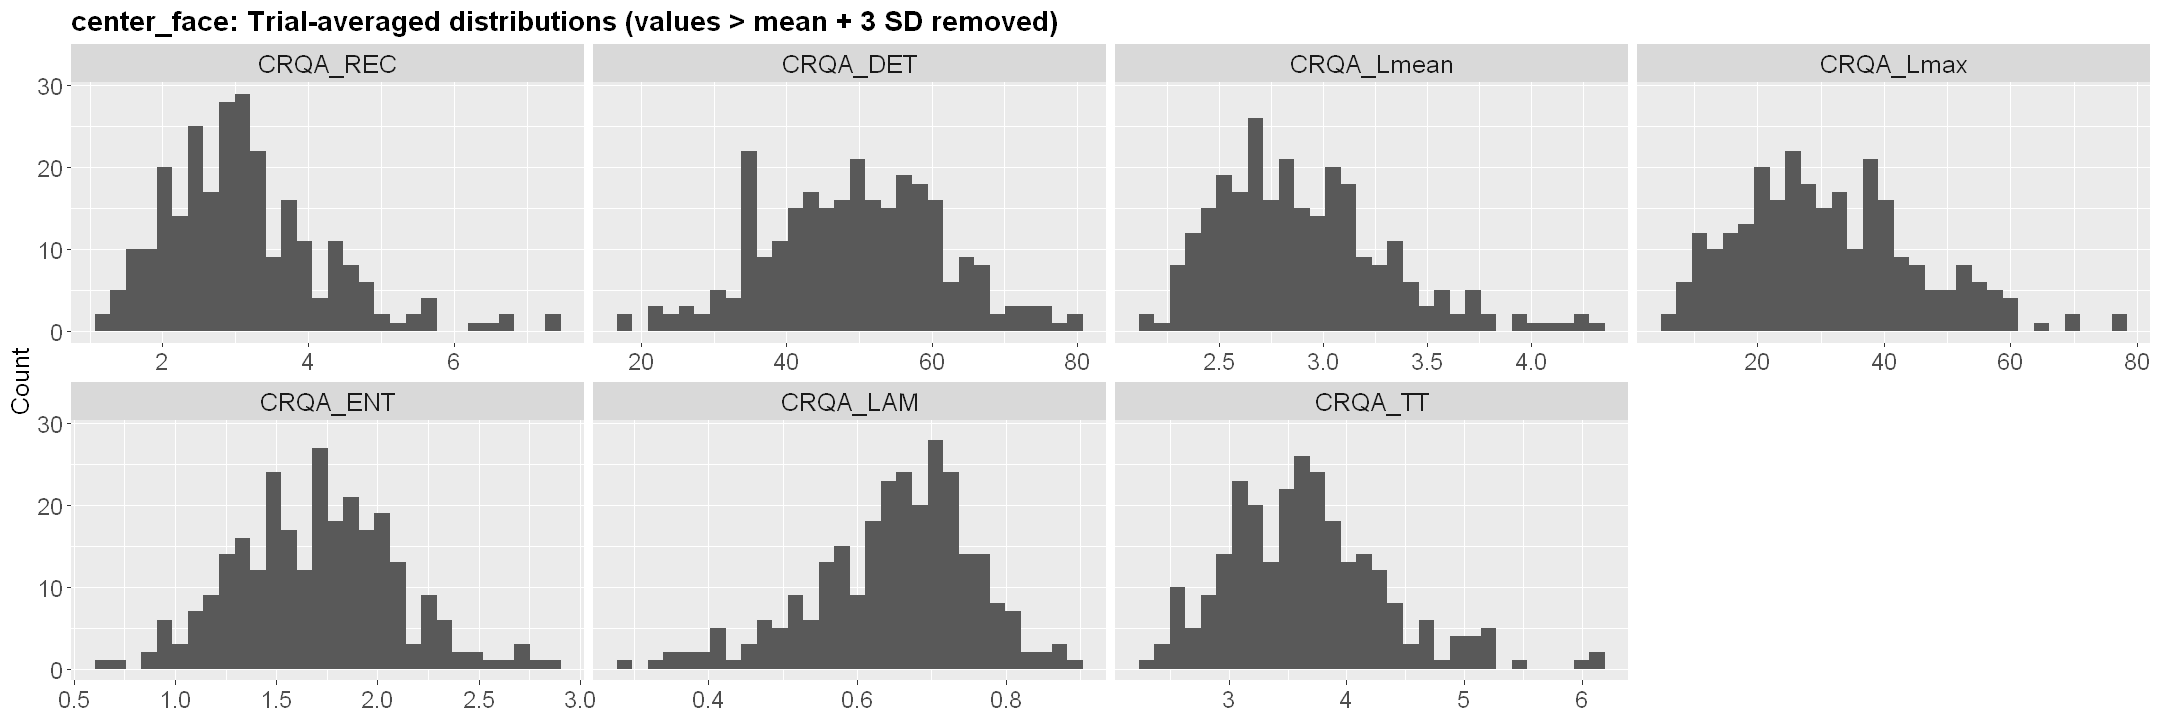

In [32]:
# Settings
SD_CUTOFF <- 3
N_COLS    <- 4
N_BINS    <- 30

# Order of metrics for plotting
metric_order <- c(
  "CRQA_REC","CRQA_DET","CRQA_Lmean","CRQA_Lmax","CRQA_ENT","CRQA_LAM","CRQA_TT"
)

# Theme for histograms
hist_theme <- theme(
  plot.title   = element_text(size = 17, face = "bold"),
  strip.text.x = element_text(size = 15),
  axis.text    = element_text(size = 14),
  axis.title   = element_text(size = 15)
)

# Convert data to long format for plotting
crqa_long <- crqa_av %>%
  pivot_longer(starts_with("CRQA_"), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric   = as.character(Metric),
    Metric_f = factor(Metric, levels = metric_order)
  )

# Set plot size
options(repr.plot.width = 18, repr.plot.height = 6)

# Run all ROIs
for (roi in sort(unique(crqa_long$ROI))) {
  plot_roi_hists(roi, crqa_long, sd_cutoff = SD_CUTOFF, ncol = N_COLS)
}

### Log transform

In [18]:
# Log transform the following: Lmax (all ROIs), REC (body only), DET (body only)
# Lmean not transformed as log does not help normality

library(dplyr)
library(tidyr)

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------
SD_CUTOFF <- 3   # keep consistent with diagnostics

# ------------------------------------------------------------
# Long-format CRQA data (assumes crqa_av already exists)
# ------------------------------------------------------------
crqa_long <- crqa_av %>%
  pivot_longer(
    starts_with("CRQA_"),
    names_to = "Metric",
    values_to = "Value_raw"
  ) %>%
  mutate(
    Metric = as.character(Metric)
  )

# ------------------------------------------------------------
# SD-based trimming (per ROI × Metric)
# ------------------------------------------------------------
crqa_stats <- crqa_long %>%
  group_by(ROI, Metric) %>%
  summarise(
    mean_val = mean(Value_raw, na.rm = TRUE),
    sd_val   = sd(Value_raw, na.rm = TRUE),
    cutoff   = mean_val + SD_CUTOFF * sd_val,
    .groups  = "drop"
  )

crqa_trim <- crqa_long %>%
  left_join(crqa_stats, by = c("ROI", "Metric")) %>%
  mutate(
    is_outlier_sd = is.finite(Value_raw) & (Value_raw > cutoff)
  ) %>%
  filter(!is_outlier_sd) %>%
  select(-mean_val, -sd_val, -cutoff, -is_outlier_sd)

# ------------------------------------------------------------
# Selective transformation for modelling
# ------------------------------------------------------------
crqa_model <- crqa_trim %>%
  mutate(
    Value_model = case_when(
      Metric == "CRQA_Lmax" ~ log1p(Value_raw),
      ROI == "body" & Metric %in% c("CRQA_REC", "CRQA_DET") ~ log1p(Value_raw),
      TRUE ~ Value_raw
    ),
    Transform = case_when(
      Metric == "CRQA_Lmax" ~ "log1p",
      ROI == "body" & Metric %in% c("CRQA_REC", "CRQA_DET") ~ "log1p",
      TRUE ~ "none"
    )
  )

# ------------------------------------------------------------
# Sanity check summary (HIGHLY recommended)
# ------------------------------------------------------------
transform_summary <- crqa_model %>%
  group_by(ROI, Metric, Transform) %>%
  summarise(
    n = n(),
    .groups = "drop"
  ) %>%
  arrange(Metric, ROI)

print(transform_summary)


# A tibble: 21 × 4
   ROI         Metric    Transform     n
   <fct>       <chr>     <chr>     <int>
 1 arms        CRQA_DET  none        267
 2 body        CRQA_DET  log1p       263
 3 center_face CRQA_DET  none        268
 4 arms        CRQA_ENT  none        267
 5 body        CRQA_ENT  none        264
 6 center_face CRQA_ENT  none        268
 7 arms        CRQA_LAM  none        268
 8 body        CRQA_LAM  none        265
 9 center_face CRQA_LAM  none        268
10 arms        CRQA_Lmax log1p       264
# ℹ 11 more rows


### Mixed effects models

In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(lme4)
library(lmerTest)
library(purrr)
library(emmeans)

# Settings
CONDITION_ORDER <- c("Office", "Cafe", "Food", "Party") # baseline set to Office
PAIRWISE_ADJUST <- "tukey" # adjust method for all pairwise contrasts

# Optional: make console printing less truncated
options(
  tibble.width = Inf,
  pillar.sigfig = 4
)

#### Linear MEMs

In [43]:
# Choose linear metrics to model
linear_metric_order <- c(
  "RMS","MeanVel","StdVel","MeanAcc","StdAcc",
  "MeanVelMag","StdVelMag","MeanAccelMag","StdAccelMag"
)

linear_metric_order <- linear_metric_order[linear_metric_order %in% names(linear_av)]
stopifnot(length(linear_metric_order) > 0)

# Long format for modelling
linear_model <- linear_av %>%
  mutate(
    ROI       = as.character(ROI),
    Condition = factor(Condition, levels = CONDITION_ORDER),
    Role      = factor(Role),
    PersonID  = interaction(Session, Role, drop = TRUE)
  ) %>%
  pivot_longer(
    cols      = all_of(linear_metric_order),
    names_to  = "Metric",
    values_to = "Value_model"
  ) %>%
  mutate(
    Metric = factor(Metric, levels = linear_metric_order)
  ) %>%
  filter(is.finite(Value_model))

# Fit MEMs for each ROI × Metric
nested_models <- linear_model %>%
  group_by(ROI, Metric) %>%
  nest() %>%
  mutate(
    model = map(
      data,
      ~ lmer(
        Value_model ~ Condition + (1 | Session) + (1 | PersonID),
        data = .x,
        REML = TRUE
      )
    ),
    emms  = map(model, ~ emmeans(.x, ~ Condition)),
    pairs = map(emms,  ~ pairs(.x, adjust = PAIRWISE_ADJUST))
  )

# Print full model summary output for each ROI × Metric
walk2(
  nested_models$ROI,
  nested_models$Metric,
  ~ {
    cat("\n====================================================\n")
    cat("MODEL SUMMARY\n")
    cat("ROI:", as.character(.x), " | Metric:", as.character(.y), "\n")
    cat("Baseline condition (reference):", CONDITION_ORDER[1], "\n")
    cat("Model: Value_model ~ Condition + (1 | Session) + (1 | PersonID)\n")
    cat("====================================================\n")

    m <- nested_models$model[
      nested_models$ROI == .x &
        nested_models$Metric == .y
    ][[1]]

    print(summary(m))
  }
)

# Print Estimated Marginal Means (EMMs) for each ROI × Metric
walk2(
  nested_models$ROI,
  nested_models$Metric,
  ~ {
    cat("\n====================================================\n")
    cat("ESTIMATED MARGINAL MEANS (Condition)\n")
    cat("ROI:", as.character(.x), " | Metric:", as.character(.y), "\n")
    cat("====================================================\n")

    emm <- nested_models$emms[
      nested_models$ROI == .x &
        nested_models$Metric == .y
    ][[1]]

    print(emm)
  }
)

# Print all pairwise condition comparisons (Tukey adjusted)
walk2(
  nested_models$ROI,
  nested_models$Metric,
  ~ {
    cat("\n====================================================\n")
    cat("PAIRWISE COMPARISONS (Condition)\n")
    cat("ROI:", as.character(.x), " | Metric:", as.character(.y), "\n")
    cat("Adjustment:", PAIRWISE_ADJUST, "\n")
    cat("====================================================\n")

    pw <- nested_models$pairs[
      nested_models$ROI == .x &
        nested_models$Metric == .y
    ][[1]]

    print(pw)
  }
)

boundary (singular) fit: see help('isSingular')

Warning message:
"There was 1 warning in `mutate()`.
ℹ In argument: `model = map(...)`.
ℹ In group 21: `ROI = "center_face"` `Metric = StdVel`.
Caused by warning in `checkConv()`:
! Model failed to converge with max|grad| = 0.00320359 (tol = 0.002, component 1)"



MODEL SUMMARY
ROI: arms  | Metric: RMS 
Baseline condition (reference): Office 
Model: Value_model ~ Condition + (1 | Session) + (1 | PersonID)
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Value_model ~ Condition + (1 | Session) + (1 | PersonID)
   Data: .x

REML criterion at convergence: -2627.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.5180 -0.5819 -0.0591  0.4727  3.5464 

Random effects:
 Groups   Name        Variance  Std.Dev.
 PersonID (Intercept) 0.0004854 0.02203 
 Session  (Intercept) 0.0001595 0.01263 
 Residual             0.0002842 0.01686 
Number of obs: 546, groups:  PersonID, 93; Session, 47

Fixed effects:
                Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)    5.950e-02  3.114e-03 5.201e+01  19.108  < 2e-16 ***
ConditionCafe  1.874e-03  2.051e-03 4.504e+02   0.914    0.361    
ConditionFood  1.435e-02  2.031e-03 4.514e+02   7.067 6.06e-12 ***
ConditionParty 2.391e-02  2.0

#### Cross-correlation MEMs

In [41]:
# Choose xcorr metrics to model
xcorr_metric_order <- c(
  "XCorr_VelMag_rmax",
  "XCorr_VelMag_rmax_abs",
  "XCorr_VelMag_r0",
  "XCorr_VelMag_r0_abs"
)

# Long format for modelling
xcorr_model <- xcorr_av %>%
  mutate(
    ROI       = as.character(ROI),
    Condition = factor(Condition, levels = CONDITION_ORDER)
  ) %>%
  pivot_longer(
    cols      = all_of(xcorr_metric_order),
    names_to  = "Metric",
    values_to = "Value_model"
  ) %>%
  mutate(
    Metric = factor(Metric, levels = xcorr_metric_order)
  ) %>%
  filter(is.finite(Value_model))

# Fit MEMs for each ROI × Metric
nested_models <- xcorr_model %>%
  group_by(ROI, Metric) %>%
  nest() %>%
  mutate(
    model = map(
      data,
      ~ lmer(
        Value_model ~ Condition + (1 | Session),
        data = .x,
        REML = TRUE
      )
    ),
    emms  = map(model, ~ emmeans(.x, ~ Condition)),
    pairs = map(emms,  ~ pairs(.x, adjust = PAIRWISE_ADJUST))
  )

# Print full model summary output for each ROI × Metric
walk2(
  nested_models$ROI,
  nested_models$Metric,
  ~ {
    cat("\n====================================================\n")
    cat("MODEL SUMMARY\n")
    cat("ROI:", as.character(.x), " | Metric:", as.character(.y), "\n")
    cat("Baseline condition (reference):", CONDITION_ORDER[1], "\n")
    cat("Model: Value_model ~ Condition + (1 | Session)\n")
    cat("====================================================\n")

    m <- nested_models$model[
      nested_models$ROI == .x &
        nested_models$Metric == .y
    ][[1]]

    print(summary(m))
  }
)
# Print Estimated Marginal Means (EMMs) for each ROI × Metric
walk2(
  nested_models$ROI,
  nested_models$Metric,
  ~ {
    cat("\n====================================================\n")
    cat("ESTIMATED MARGINAL MEANS (Condition)\n")
    cat("ROI:", as.character(.x), " | Metric:", as.character(.y), "\n")
    cat("====================================================\n")

    emm <- nested_models$emms[
      nested_models$ROI == .x &
        nested_models$Metric == .y
    ][[1]]

    print(emm)
  }
)
# Print all pairwise condition comparisons (Tukey adjusted)
walk2(
  nested_models$ROI,
  nested_models$Metric,
  ~ {
    cat("\n====================================================\n")
    cat("PAIRWISE COMPARISONS (Condition)\n")
    cat("ROI:", as.character(.x), " | Metric:", as.character(.y), "\n")
    cat("Adjustment:", PAIRWISE_ADJUST, "\n")
    cat("====================================================\n")

    pw <- nested_models$pairs[
      nested_models$ROI == .x &
        nested_models$Metric == .y
    ][[1]]

    print(pw)
  }
)


MODEL SUMMARY
ROI: arms  | Metric: XCorr_VelMag_rmax 
Baseline condition (reference): Office 
Model: Value_model ~ Condition + (1 | Session)
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Value_model ~ Condition + (1 | Session)
   Data: .x

REML criterion at convergence: -981.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0457 -0.6913 -0.1583  0.5543  3.5555 

Random effects:
 Groups   Name        Variance  Std.Dev.
 Session  (Intercept) 0.0001878 0.01370 
 Residual             0.0011962 0.03459 
Number of obs: 268, groups:  Session, 46

Fixed effects:
                 Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)      0.145658   0.003630  96.200073  40.125   <2e-16 ***
ConditionCafe   -0.001482   0.006016 218.941576  -0.246    0.806    
ConditionFood    0.007995   0.005924 220.783823   1.350    0.179    
ConditionParty   0.005541   0.005971 220.350937   0.928    0.354    
---
Signif. codes:  0 '***' 

#### Cross recurrence MEMs

In [42]:
# Choose CRQA metrics to model
CRQA_METRICS_TO_MODEL <- c(
  "CRQA_REC",
  "CRQA_DET",
  "CRQA_Lmean",
  "CRQA_Lmax",
  "CRQA_ENT",
  "CRQA_LAM",
  "CRQA_TT"
)

# Long format for modelling
crqa_model <- crqa_model %>%
  mutate(
    ROI       = as.character(ROI),
    Condition = factor(Condition, levels = CONDITION_ORDER),
    Metric    = as.character(Metric)
  ) %>%
  filter(Metric %in% CRQA_METRICS_TO_MODEL) %>%
  filter(is.finite(Value_model))

# Fit MEMs for each ROI × Metric
nested_models <- crqa_model %>%
  group_by(ROI, Metric) %>%
  nest() %>%
  mutate(
    model = map(
      data,
      ~ lmer(
        Value_model ~ Condition + (1 | Session),
        data = .x,
        REML = TRUE
      )
    ),
    emms = map(model, ~ emmeans(.x, ~ Condition)),
    pairs = map(emms, ~ pairs(.x, adjust = PAIRWISE_ADJUST))
  )

# Print full model summary output for each ROI × Metric
walk2(
  nested_models$ROI,
  nested_models$Metric,
  ~ {
    cat("\n====================================================\n")
    cat("MODEL SUMMARY\n")
    cat("ROI:", .x, " | Metric:", .y, "\n")
    cat("Baseline condition (reference):", CONDITION_ORDER[1], "\n")
    cat("Model: Value_model ~ Condition + (1 | Session)\n")
    cat("====================================================\n")

    m <- nested_models$model[
      nested_models$ROI == .x &
        nested_models$Metric == .y
    ][[1]]

    print(summary(m))
  }
)

# Print Estimated Marginal Means (EMMs) for each ROI × Metric
walk2(
  nested_models$ROI,
  nested_models$Metric,
  ~ {
    cat("\n====================================================\n")
    cat("ESTIMATED MARGINAL MEANS (Condition)\n")
    cat("ROI:", .x, " | Metric:", .y, "\n")
    cat("====================================================\n")

    emm <- nested_models$emms[
      nested_models$ROI == .x &
        nested_models$Metric == .y
    ][[1]]

    print(emm)
  }
)

# Print all pairwise condition comparisons (Tukey adjusted)
walk2(
  nested_models$ROI,
  nested_models$Metric,
  ~ {
    cat("\n====================================================\n")
    cat("PAIRWISE COMPARISONS (Condition)\n")
    cat("ROI:", .x, " | Metric:", .y, "\n")
    cat("Adjustment:", PAIRWISE_ADJUST, "\n")
    cat("====================================================\n")

    pw <- nested_models$pairs[
      nested_models$ROI == .x &
        nested_models$Metric == .y
    ][[1]]

    print(pw)
  }
)


MODEL SUMMARY
ROI: arms  | Metric: CRQA_REC 
Baseline condition (reference): Office 
Model: Value_model ~ Condition + (1 | Session)
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: Value_model ~ Condition + (1 | Session)
   Data: .x

REML criterion at convergence: 1019.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0617 -0.6652 -0.1400  0.4769  3.3206 

Random effects:
 Groups   Name        Variance Std.Dev.
 Session  (Intercept) 1.961    1.400   
 Residual             2.004    1.416   
Number of obs: 264, groups:  Session, 46

Fixed effects:
               Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)      3.4289     0.2423  60.3426  14.152  < 2e-16 ***
ConditionCafe    0.4670     0.2474 215.5205   1.888 0.060424 .  
ConditionFood    0.9484     0.2442 216.7089   3.884 0.000137 ***
ConditionParty   1.1926     0.2460 216.4636   4.848 2.38e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1